# Student Academic Success Prediction — Phase 1
## Problem Definition, EDA, Preprocessing & Feature Engineering

**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Task:** Classify student `final_result` into: Distinction, Pass, Fail, Withdrawn  
**Source:** https://analyse.kmi.open.ac.uk/open_dataset

---

### 1. Problem Definition

The Open University (UK) collects detailed digital footprints of its distance-learning students. Our goal is to **predict whether a student will pass, fail, earn a distinction, or withdraw** from a module, using:

- **Demographics** — age, gender, region, deprivation index, prior education, disability  
- **Engagement** — daily clicks on the Virtual Learning Environment (VLE)  
- **Assessment performance** — scores, submission timing  
- **Registration behaviour** — how early they enrolled  

This is a **multi-class classification** problem with practical value: early identification of at-risk students enables timely intervention.

#### Prediction Point

In a realistic deployment, this model would be used as an **early-warning system** — making predictions at a specific day into the module, using only the data available up to that point. This means:

- **VLE engagement data** is filtered to only include clicks up to the prediction day  
- **Assessment scores** are filtered to only include submissions made before the prediction day  
- **Demographics and registration** are always available (they exist before the module starts)  

We define a configurable `PREDICTION_DAY` parameter. Setting it to, for example, day 100 means we only use the first ~100 days of behavioural data — simulating a prediction made roughly halfway through a typical 240-day module. This allows us to answer: *"Using only the data available at this point, can we identify who will fail or withdraw?"*

In Phase 2, we will experiment with multiple prediction days to study how accuracy improves as more data becomes available.

---

### Dataset Structure

The OULAD is a **relational** dataset with 7 CSV tables linked by composite keys:

| Table | Rows | Description |
|---|---|---|
| `courses` | 22 | Module-presentation metadata (length) |
| `assessments` | 206 | Assessment schedule & weights |
| `vle` | 6 364 | VLE page/material catalogue |
| `studentInfo` | 32 593 | Demographics + **target** (`final_result`) |
| `studentRegistration` | 32 593 | Registration & un-registration dates |
| `studentAssessment` | 173 912 | Submitted scores per assessment |
| `studentVle` | ~10.6 M | Daily click logs per student per VLE page |

**Join keys:** `code_module` + `code_presentation` link courses/assessments/vle; adding `id_student` links to student tables.

## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")

Libraries loaded.


In [2]:
courses = pd.read_csv('datasets/courses.csv')
assessments = pd.read_csv('datasets/assessments.csv')
vle = pd.read_csv('datasets/vle.csv')
student_info = pd.read_csv('datasets/studentInfo.csv')
student_reg = pd.read_csv('datasets/studentRegistration.csv')
student_assess = pd.read_csv('datasets/studentAssessment.csv')
student_vle = pd.read_csv('datasets/studentVle.csv')

tables = {
    'courses': courses, 'assessments': assessments, 'vle': vle,
    'studentInfo': student_info, 'studentRegistration': student_reg,
    'studentAssessment': student_assess, 'studentVle': student_vle
}

for name, df in tables.items():
    print(f"{name:25s}  shape={str(df.shape):15s}  missing(?)={int((df == '?').sum().sum()):>6}")

courses                    shape=(22, 3)          missing(?)=     0
assessments                shape=(206, 6)         missing(?)=    11
vle                        shape=(6364, 6)        missing(?)= 10486
studentInfo                shape=(32593, 12)      missing(?)=  1111
studentRegistration        shape=(32593, 5)       missing(?)= 22566
studentAssessment          shape=(173912, 5)      missing(?)=   173
studentVle                 shape=(10655280, 6)    missing(?)=     0


The `?` character is used as a placeholder for missing values across several tables. We will handle these during preprocessing. The largest table by far is `studentVle` with over 10 million rows of daily click logs.

In [3]:
# Summary of missing values ('?') across all tables
print('Missing values summary ("?" placeholders):')
print(f'  studentInfo.imd_band:              {(student_info.imd_band == "?").sum():>5} / {len(student_info)} ({(student_info.imd_band == "?").mean()*100:.1f}%)')
print(f'  studentAssessment.score:            {(student_assess.score == "?").sum():>5} / {len(student_assess)} ({(student_assess.score == "?").mean()*100:.2f}%)')
print(f'  studentRegistration.date_reg:       {(student_reg.date_registration == "?").sum():>5} / {len(student_reg)} ({(student_reg.date_registration == "?").mean()*100:.2f}%)')
print(f'  studentRegistration.date_unreg:     {(student_reg.date_unregistration == "?").sum():>5} / {len(student_reg)} (expected — means student stayed)')
print(f'  assessments.date:                   {(assessments.date == "?").sum():>5} / {len(assessments)} (exams have no fixed date)')
print(f'  vle.week_from/week_to:              {(vle.week_from == "?").sum():>5} / {len(vle)} (materials with no scheduled week)')

Missing values summary ("?" placeholders):
  studentInfo.imd_band:               1111 / 32593 (3.4%)
  studentAssessment.score:              173 / 173912 (0.10%)
  studentRegistration.date_reg:          45 / 32593 (0.14%)
  studentRegistration.date_unreg:     22521 / 32593 (expected — means student stayed)
  assessments.date:                      11 / 206 (exams have no fixed date)
  vle.week_from/week_to:               5243 / 6364 (materials with no scheduled week)


### Feature Descriptions per Table

Before starting the EDA, we examine the columns, data types, and first few rows of each table.

In [4]:
print('=' * 70)
print('COURSES (22 rows) — one row per module-presentation')
print('=' * 70)
print(courses.dtypes.to_string())
print(courses.head(3).to_string())
print(f'\n  code_module:                  module identifier (7 modules: {sorted(courses.code_module.unique())})')
print(f'  code_presentation:            semester (B=February, J=October) + year')
print(f'  module_presentation_length:   duration in days ({courses.module_presentation_length.min()}–{courses.module_presentation_length.max()})')

COURSES (22 rows) — one row per module-presentation
code_module                   object
code_presentation             object
module_presentation_length     int64
  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268

  code_module:                  module identifier (7 modules: ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG'])
  code_presentation:            semester (B=February, J=October) + year
  module_presentation_length:   duration in days (234–269)


In [5]:
print('=' * 70)
print('STUDENT INFO (32,593 rows) — one row per student-module registration')
print('=' * 70)
print(student_info.dtypes.to_string())
print('\n', student_info.head(3).to_string())
print(f'\n  id_student:           unique student ID ({student_info.id_student.nunique()} unique students)')
print(f'  gender:               {sorted(student_info.gender.unique())}')
print(f'  region:               {student_info.region.nunique()} UK regions')
print(f'  highest_education:    {sorted(student_info.highest_education.unique())}')
print(f'  imd_band:             Index of Multiple Deprivation (socioeconomic decile)')
print(f'  age_band:             {sorted(student_info.age_band.unique())}')
print(f'  num_of_prev_attempts: times student previously attempted this module (0–{student_info.num_of_prev_attempts.max()})')
print(f'  studied_credits:      total credits currently studying ({student_info.studied_credits.min()}–{student_info.studied_credits.max()})')
print(f'  disability:           {sorted(student_info.disability.unique())}')
print(f'  final_result:         TARGET — {sorted(student_info.final_result.unique())}')

STUDENT INFO (32,593 rows) — one row per student-module registration
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object

   code_module code_presentation  id_student gender                region      highest_education imd_band age_band  num_of_prev_attempts  studied_credits disability final_result
0         AAA             2013J       11391      M   East Anglian Region       HE Qualification  90-100%     55<=                     0              240          N         Pass
1         AAA             2013J       28400      F              Scotland       HE Qualification   20-30%    35-55                     0               60          N         Pass
2         AAA             

In [6]:
print('=' * 70)
print('ASSESSMENTS (206 rows) — assessment schedule per module-presentation')
print('=' * 70)
print(assessments.dtypes.to_string())
print('\n', assessments.head(3).to_string())
print(f'\n  id_assessment:    unique assessment ID')
print(f'  assessment_type:  {sorted(assessments.assessment_type.unique())} (TMA=Tutor Marked, CMA=Computer Marked)')
print(f'  date:             submission deadline in days from module start (? for exams)')
print(f'  weight:           percentage weight of the assessment')

ASSESSMENTS (206 rows) — assessment schedule per module-presentation
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                  object
weight               float64

   code_module code_presentation  id_assessment assessment_type date  weight
0         AAA             2013J           1752             TMA   19    10.0
1         AAA             2013J           1753             TMA   54    20.0
2         AAA             2013J           1754             TMA  117    20.0

  id_assessment:    unique assessment ID
  assessment_type:  ['CMA', 'Exam', 'TMA'] (TMA=Tutor Marked, CMA=Computer Marked)
  date:             submission deadline in days from module start (? for exams)
  weight:           percentage weight of the assessment


In [7]:
print('=' * 70)
print('STUDENT ASSESSMENT (173,912 rows) — one row per student submission')
print('=' * 70)
print(student_assess.dtypes.to_string())
print('\n', student_assess.head(3).to_string())
print(f'\n  id_assessment:    links to assessments table')
print(f'  id_student:       links to studentInfo')
print(f'  date_submitted:   day the student submitted (relative to module start)')
print(f'  is_banked:        1 if result transferred from previous attempt')
print(f'  score:            0–100 (? = missing)')

STUDENT ASSESSMENT (173,912 rows) — one row per student submission
id_assessment      int64
id_student         int64
date_submitted     int64
is_banked          int64
score             object

    id_assessment  id_student  date_submitted  is_banked score
0           1752       11391              18          0    78
1           1752       28400              22          0    70
2           1752       31604              17          0    72

  id_assessment:    links to assessments table
  id_student:       links to studentInfo
  date_submitted:   day the student submitted (relative to module start)
  is_banked:        1 if result transferred from previous attempt
  score:            0–100 (? = missing)


In [8]:
print('=' * 70)
print('STUDENT REGISTRATION (32,593 rows) — registration dates per student-module')
print('=' * 70)
print(student_reg.dtypes.to_string())
print('\n', student_reg.head(3).to_string())
print(f'\n  date_registration:    days relative to module start (negative = before start)')
print(f'  date_unregistration:  day student unregistered (? = did not unregister)')

STUDENT REGISTRATION (32,593 rows) — registration dates per student-module
code_module            object
code_presentation      object
id_student              int64
date_registration      object
date_unregistration    object

   code_module code_presentation  id_student date_registration date_unregistration
0         AAA             2013J       11391              -159                   ?
1         AAA             2013J       28400               -53                   ?
2         AAA             2013J       30268               -92                  12

  date_registration:    days relative to module start (negative = before start)
  date_unregistration:  day student unregistered (? = did not unregister)


In [9]:
print('=' * 70)
print('VLE (6,364 rows) — catalogue of VLE materials per module')
print('=' * 70)
print(vle.dtypes.to_string())
print('\n', vle.head(3).to_string())
print(f'\n  id_site:         unique material/page ID')
print(f'  activity_type:   {sorted(vle.activity_type.unique())}')
print(f'  week_from/to:    scheduled availability window (? = unscheduled)')

VLE (6,364 rows) — catalogue of VLE materials per module
id_site               int64
code_module          object
code_presentation    object
activity_type        object
week_from            object
week_to              object

    id_site code_module code_presentation activity_type week_from week_to
0   546943         AAA             2013J      resource         ?       ?
1   546712         AAA             2013J     oucontent         ?       ?
2   546998         AAA             2013J      resource         ?       ?

  id_site:         unique material/page ID
  activity_type:   ['dataplus', 'dualpane', 'externalquiz', 'folder', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent', 'ouelluminate', 'ouwiki', 'page', 'questionnaire', 'quiz', 'repeatactivity', 'resource', 'sharedsubpage', 'subpage', 'url']
  week_from/to:    scheduled availability window (? = unscheduled)


In [10]:
print('=' * 70)
print(f'STUDENT VLE ({len(student_vle):,} rows) — daily click logs per student per VLE page')
print('=' * 70)
print(student_vle.dtypes.to_string())
print('\n', student_vle.head(3).to_string())
print(f'\n  id_site:     links to vle table')
print(f'  date:        day of interaction (relative to module start)')
print(f'  sum_click:   number of clicks on that page on that day')

STUDENT VLE (10,655,280 rows) — daily click logs per student per VLE page
code_module          object
code_presentation    object
id_student            int64
id_site               int64
date                  int64
sum_click             int64

   code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1

  id_site:     links to vle table
  date:        day of interaction (relative to module start)
  sum_click:   number of clicks on that page on that day


The tables are connected through composite keys: `code_module` + `code_presentation` links courses, assessments, and VLE materials. Adding `id_student` links to all student-level tables.

## 3. Exploratory Data Analysis

We analyse each table individually, then examine relationships with the target variable `final_result`.

*Note: The EDA is performed on the **full dataset** (no time cutoff) to understand all available patterns. Time-based filtering is applied during preprocessing via the `build_dataset()` function (Section 4.2).*

### 3.1 Courses and Module Difficulty

In [11]:
print(courses.to_string(index=False))
print(f"\nModules: {courses.code_module.nunique()}, Presentations: {courses.shape[0]}")
print(f"Module length range: {courses.module_presentation_length.min()}–{courses.module_presentation_length.max()} days")

code_module code_presentation  module_presentation_length
        AAA             2013J                         268
        AAA             2014J                         269
        BBB             2013J                         268
        BBB             2014J                         262
        BBB             2013B                         240
        BBB             2014B                         234
        CCC             2014J                         269
        CCC             2014B                         241
        DDD             2013J                         261
        DDD             2014J                         262
        DDD             2013B                         240
        DDD             2014B                         241
        EEE             2013J                         268
        EEE             2014J                         269
        EEE             2014B                         241
        FFF             2013J                         268
        FFF   

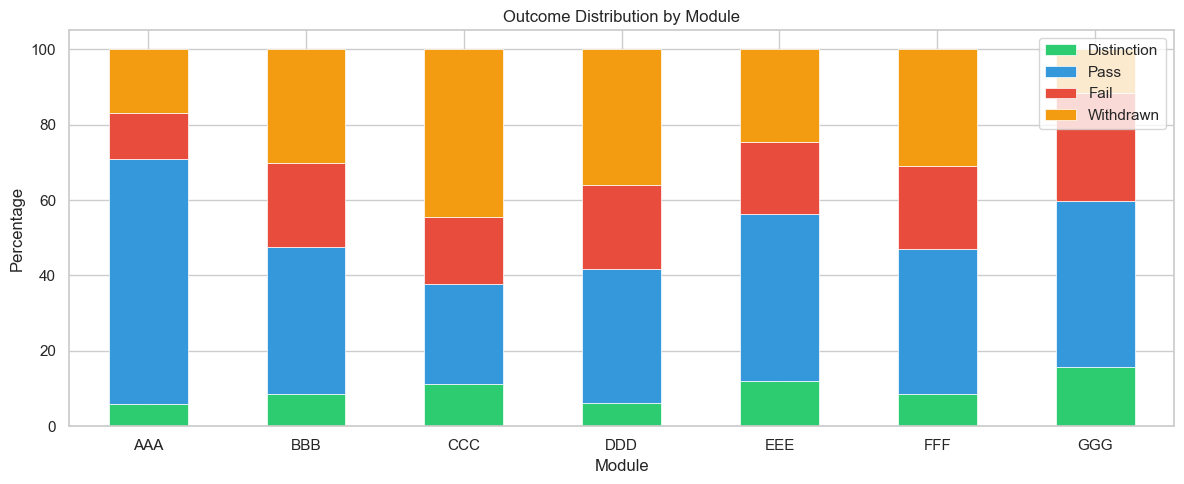

In [12]:
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(12, 5))
ct = pd.crosstab(student_info['code_module'], student_info['final_result'], normalize='index') * 100
ct = ct.reindex(columns=order)
ct.plot.bar(stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Outcome Distribution by Module')
ax.set_ylabel('Percentage'); ax.set_xlabel('Module')
ax.legend(title='', loc='upper right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Module difficulty varies considerably.** Some modules (e.g., DDD, CCC) have noticeably higher failure and withdrawal rates than others.

#### Temporal Stability Across Presentations

The dataset spans four semesters (2013B, 2013J, 2014B, 2014J). We check whether outcome distributions are stable across time.

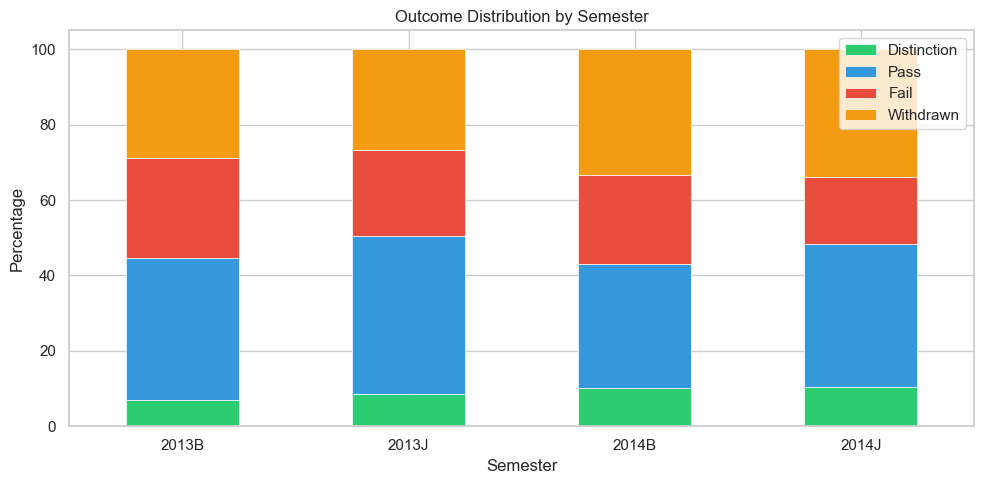

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ct_time = pd.crosstab(student_info['code_presentation'], student_info['final_result'], normalize='index') * 100
ct_time = ct_time.reindex(columns=order)
ct_time.plot.bar(stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Outcome Distribution by Semester')
ax.set_ylabel('Percentage'); ax.set_xlabel('Semester')
ax.legend(title='', loc='upper right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**The data shows a temporal trend:** withdrawal rates increased from 2013 (27-29%) to 2014 (33-34%), while failure rates decreased slightly. We note this as a limitation — a model trained on 2013 data might not generalise perfectly to 2014. For this project, we pool all semesters together but acknowledge that a time-aware split could be explored in future work.

### 3.2 Target Variable — `final_result`

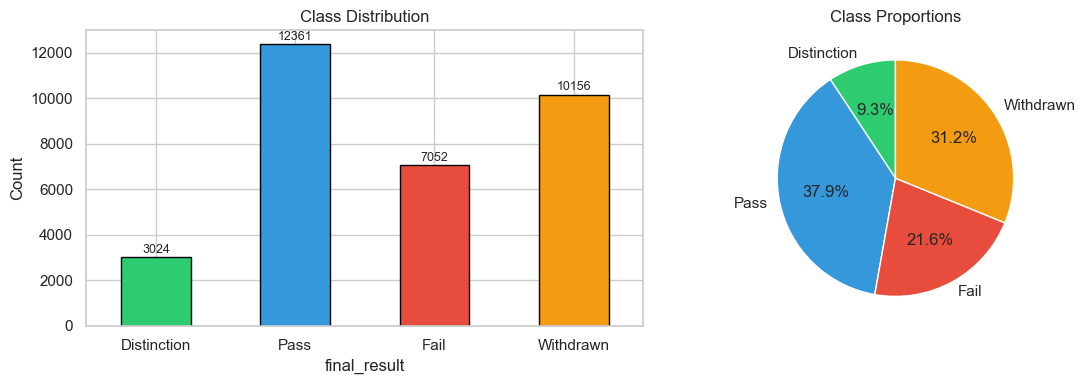


Class balance:
final_result
Distinction     9.3
Pass           37.9
Fail           21.6
Withdrawn      31.2


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = student_info.final_result.value_counts().reindex(order)
counts.plot.bar(ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f'{v}', ha='center', fontsize=9)

counts.plot.pie(ax=axes[1], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_ylabel(''); axes[1].set_title('Class Proportions')
plt.tight_layout()
plt.show()

print("\nClass balance:")
print((counts / counts.sum() * 100).round(1).to_string())

**Key finding — Class Imbalance:** Pass (37.9%), Withdrawn (31.2%), Fail (21.6%), Distinction (9.3%). Over **52% of students either fail or withdraw**. We will address this in Phase 2 through class weighting or oversampling.

### 3.3 Demographics vs Outcome

We examine how each demographic feature relates to the target, supplementing visual analysis with **Chi-square tests** to confirm significance.

#### 3.3.1 Gender, Age, Education, and Disability

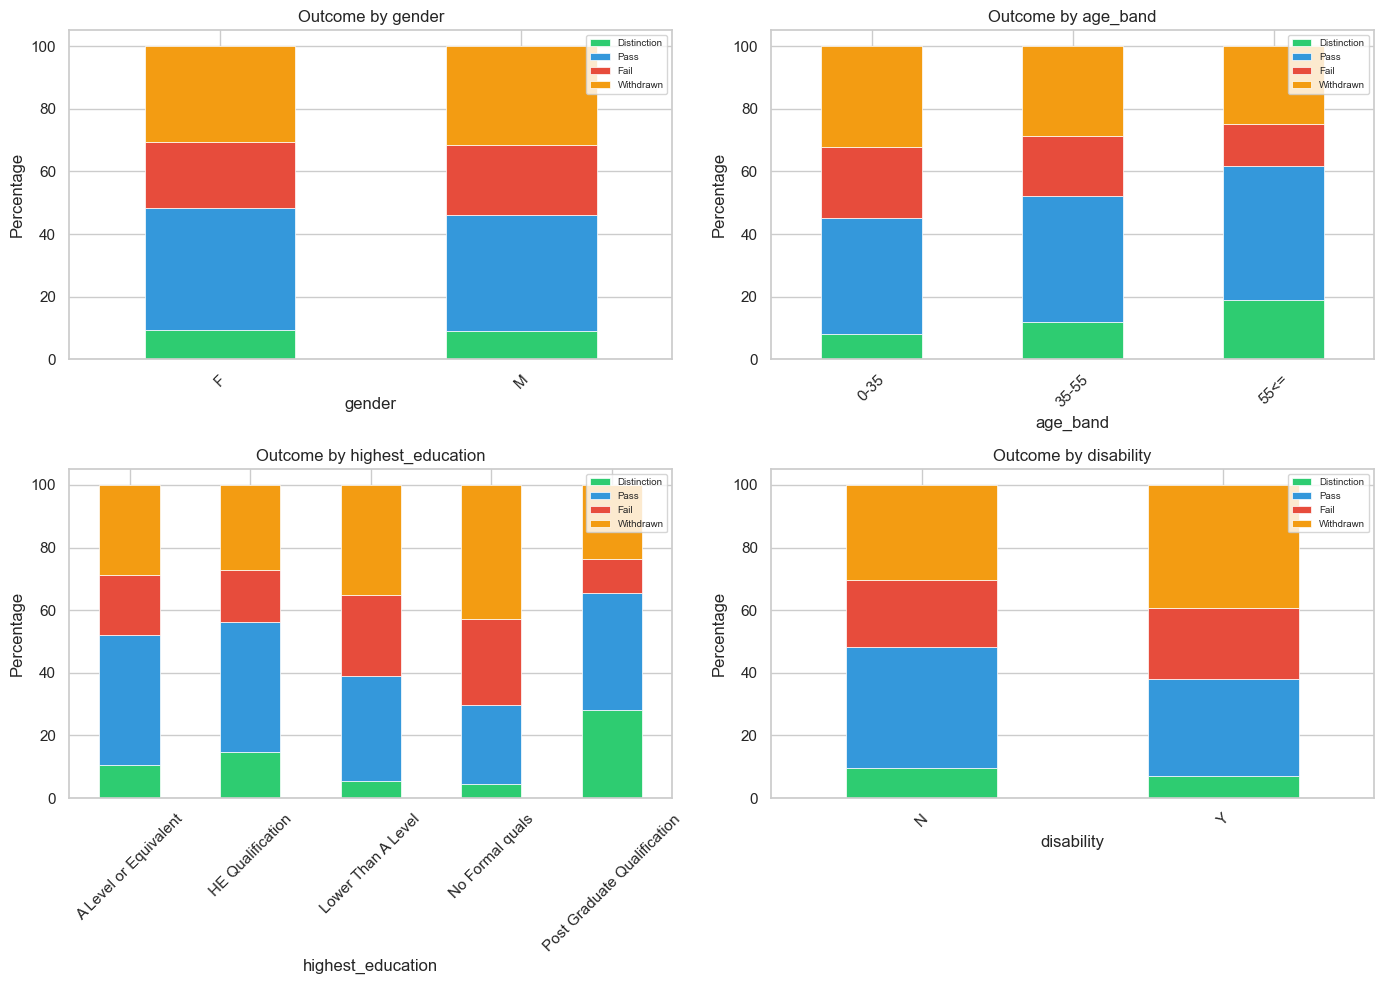

In [15]:
demo_cols = ['gender', 'age_band', 'highest_education', 'disability']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, col in enumerate(demo_cols):
    ct = pd.crosstab(student_info[col], student_info['final_result'], normalize='index') * 100
    ct = ct.reindex(columns=order)
    ct.plot.bar(stacked=True, ax=axes[i], color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Outcome by {col}'); axes[i].set_ylabel('Percentage')
    axes[i].legend(title='', fontsize=7, loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [16]:
print("Chi-square tests of independence (demographic feature vs final_result):")
print("-" * 65)
for col in demo_cols:
    ct = pd.crosstab(student_info[col], student_info['final_result'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {col:25s}  χ²={chi2:>8.1f}  dof={dof}  p={p:.2e}  {sig}")

Chi-square tests of independence (demographic feature vs final_result):
-----------------------------------------------------------------
  gender                     χ²=    16.5  dof=3  p=8.83e-04  ***
  age_band                   χ²=   222.7  dof=6  p=2.83e-45  ***
  highest_education          χ²=  1024.7  dof=12  p=9.18e-212  ***
  disability                 χ²=   138.5  dof=3  p=8.14e-30  ***


**Findings:**
- **Gender** is statistically significant (p < 0.001) but effect size is negligible (~1-2pp difference).
- **Age**: students 55+ earn Distinction at 19% vs 8.1% for 0-35.
- **Highest education** is the strongest demographic predictor: postgraduates 28.1% Distinction vs no-quals 4.6%.
- **Disability** correlates with higher withdrawal (39.3% vs 30.3%).

#### 3.3.2 Region

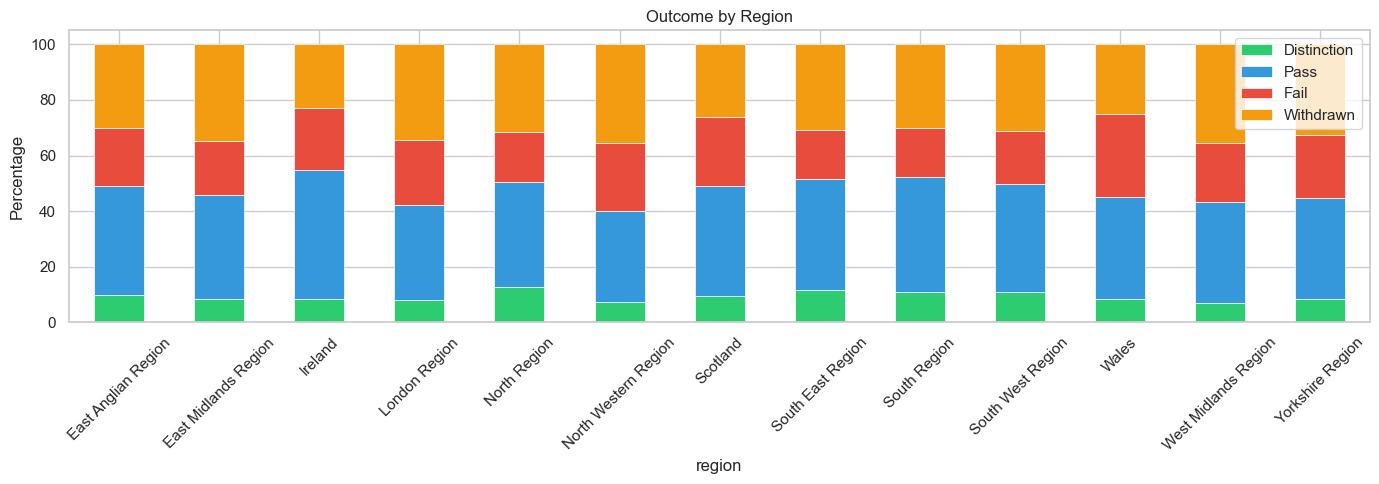

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
ct = pd.crosstab(student_info['region'], student_info['final_result'], normalize='index') * 100
ct = ct.reindex(columns=order)
ct.plot.bar(stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Outcome by Region'); ax.set_ylabel('Percentage')
ax.legend(title='', loc='upper right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Region:** Moderate variation, less dramatic than education or age. May overlap with IMD band.

#### 3.3.3 IMD Band (Index of Multiple Deprivation)

Lower percentages = **more deprived** areas. We exclude the 1,111 students (~3.4%) with missing IMD values.

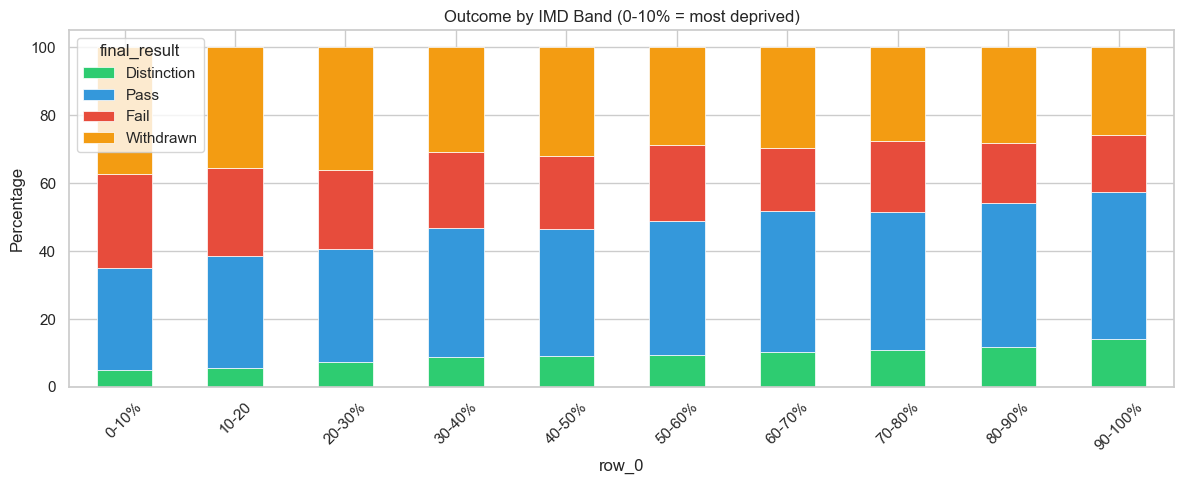

In [18]:
si_imd = student_info[student_info.imd_band != '?'].copy()
imd_order = ['0-10%','10-20','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%']
fig, ax = plt.subplots(figsize=(12, 5))
ct = pd.crosstab(pd.Categorical(si_imd['imd_band'], categories=imd_order, ordered=True),
                 si_imd['final_result'], normalize='index') * 100
ct = ct.reindex(columns=order)
ct.plot.bar(stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Outcome by IMD Band (0-10% = most deprived)')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Clear socioeconomic gradient:** most deprived (0-10%) → 37.2% withdrawal, 5.1% distinction; least deprived (90-100%) → 25.9% withdrawal, 14.1% distinction — nearly a **3x difference** in distinction rate.

#### 3.3.4 Studied Credits and Previous Attempts

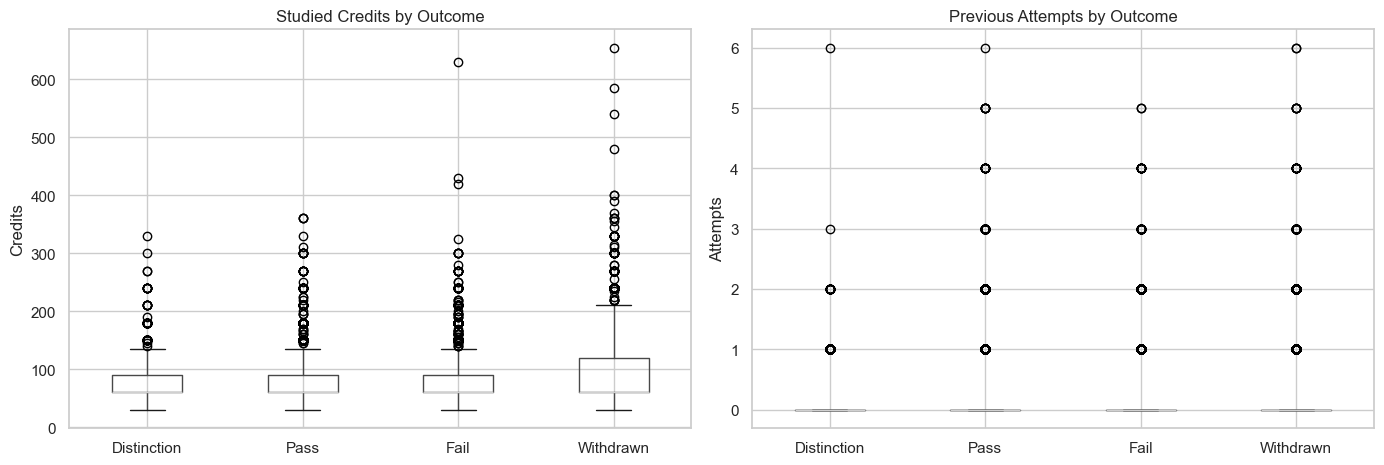

Kruskal-Wallis studied_credits ~ final_result: H=1185.0, p=1.29e-256
Kruskal-Wallis num_of_prev_attempts ~ final_result: H=499.0, p=7.97e-108


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

student_info.boxplot(column='studied_credits', by='final_result', ax=axes[0])
axes[0].set_title('Studied Credits by Outcome')
axes[0].set_xlabel(''); axes[0].set_ylabel('Credits')
plt.sca(axes[0]); plt.xticks(range(1,5), order)

student_info.boxplot(column='num_of_prev_attempts', by='final_result', ax=axes[1])
axes[1].set_title('Previous Attempts by Outcome')
axes[1].set_xlabel(''); axes[1].set_ylabel('Attempts')
plt.sca(axes[1]); plt.xticks(range(1,5), order)
plt.suptitle('')
plt.tight_layout()
plt.show()

for col in ['studied_credits', 'num_of_prev_attempts']:
    groups = [g[col].values for _, g in student_info.groupby('final_result')]
    stat, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis {col} ~ final_result: H={stat:.1f}, p={p:.2e}")

**Studied Credits:** Median is 60 across all groups. Outliers up to 655 credits are kept (may indicate overloaded students). **Previous Attempts:** Fail students average 0.25 vs 0.06 for Distinction. Both are statistically significant (Kruskal-Wallis).

### 3.4 Assessments

Assessment types:
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

Assessments with no fixed date (Exams): 11


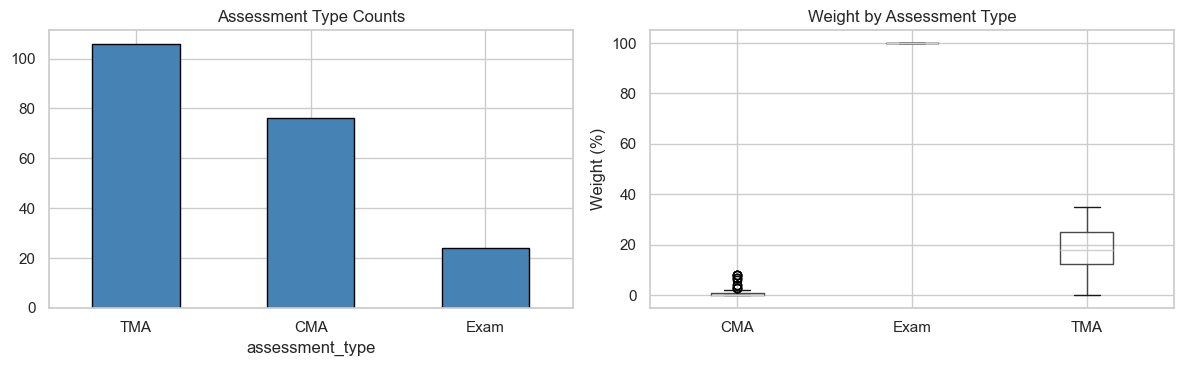

In [20]:
assessments_clean = assessments.copy()
assessments_clean['date'] = pd.to_numeric(assessments_clean['date'].replace('?', np.nan))

print("Assessment types:")
print(assessments_clean.assessment_type.value_counts())
print(f"\nAssessments with no fixed date (Exams): {assessments_clean.date.isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
assessments_clean.assessment_type.value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Assessment Type Counts'); axes[0].tick_params(axis='x', rotation=0)

assessments_clean.boxplot(column='weight', by='assessment_type', ax=axes[1])
axes[1].set_title('Weight by Assessment Type')
axes[1].set_xlabel(''); axes[1].set_ylabel('Weight (%)')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Two separate grading pools:** TMA+CMA weights sum to 100% (coursework), exams carry a separate 100%. We compute `weighted_coursework` and `exam_score` as separate features.

### 3.5 Student Assessment Scores

Total submissions: 173912
Missing scores ('?'): 173
Banked assessments: 1909
Scores = 0: 329

Score statistics:
count    173739.0
mean         75.8
std          18.8
min           0.0
25%          65.0
50%          80.0
75%          90.0
max         100.0
Name: score, dtype: float64


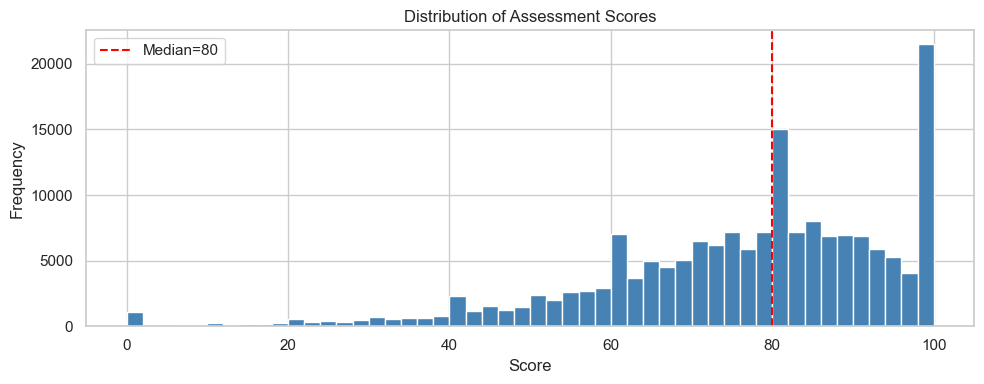

In [21]:
sa = student_assess.copy()
sa['score'] = pd.to_numeric(sa['score'].replace('?', np.nan))

print(f"Total submissions: {len(sa)}")
print(f"Missing scores ('?'): {sa.score.isna().sum()}")
print(f"Banked assessments: {sa.is_banked.sum()}")
print(f"Scores = 0: {(sa.score == 0).sum()}")
print(f"\nScore statistics:")
print(sa.score.describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
sa.score.dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(sa.score.median(), color='red', linestyle='--', label=f'Median={sa.score.median():.0f}')
ax.set_title('Distribution of Assessment Scores')
ax.set_xlabel('Score'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout()
plt.show()

**Zero scores:** 329 submissions have score = 0. These are overwhelmingly from Fail (153) and Withdrawn (86) students, split across TMA (185) and CMA (141). We treat these as **genuine zero scores** (non-submissions graded as 0) rather than missing data.

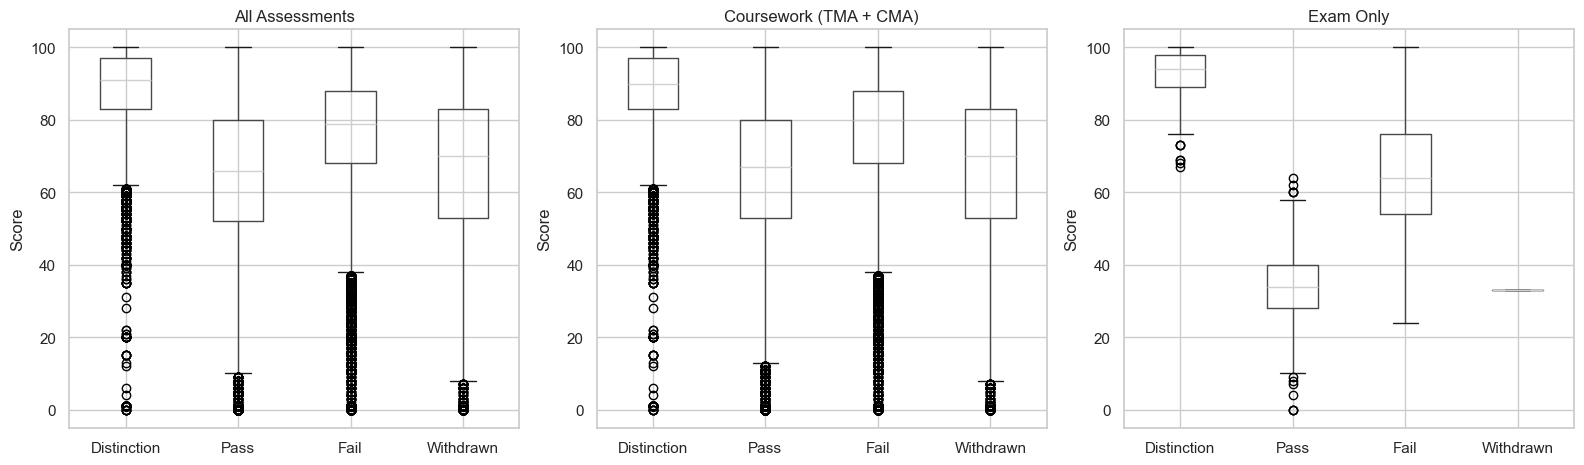

Mean COURSEWORK score by outcome:
final_result
Distinction    88.5
Pass           77.2
Fail           65.4
Withdrawn      66.1
Name: score, dtype: float64

Mean EXAM score by outcome:
final_result
Distinction    92.8
Pass           64.8
Fail           34.1
Withdrawn      33.0
Name: score, dtype: float64


In [22]:
sa_with_info = sa.merge(
    assessments[['id_assessment','code_module','code_presentation','assessment_type']],
    on='id_assessment'
).merge(
    student_info[['code_module','code_presentation','id_student','final_result']],
    on=['code_module','code_presentation','id_student'], how='inner'
)

sa_coursework = sa_with_info[sa_with_info.assessment_type.isin(['TMA','CMA'])]
sa_exam = sa_with_info[sa_with_info.assessment_type == 'Exam']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sa_with_info.boxplot(column='score', by='final_result', ax=axes[0])
axes[0].set_title('All Assessments'); axes[0].set_xlabel(''); axes[0].set_ylabel('Score')
plt.sca(axes[0]); plt.xticks(range(1,5), order)

sa_coursework.boxplot(column='score', by='final_result', ax=axes[1])
axes[1].set_title('Coursework (TMA + CMA)'); axes[1].set_xlabel(''); axes[1].set_ylabel('Score')
plt.sca(axes[1]); plt.xticks(range(1,5), order)

sa_exam.boxplot(column='score', by='final_result', ax=axes[2])
axes[2].set_title('Exam Only'); axes[2].set_xlabel(''); axes[2].set_ylabel('Score')
plt.sca(axes[2]); plt.xticks(range(1,5), order)
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Mean COURSEWORK score by outcome:')
print(sa_coursework.groupby('final_result')['score'].mean().reindex(order).round(1))
print('\nMean EXAM score by outcome:')
print(sa_exam.groupby('final_result')['score'].mean().reindex(order).round(1))

**Scores clearly separate outcomes.** Coursework: Distinction 88.5, Pass 77.2, Fail 65.4, Withdrawn 66.1. Exam gap is much larger: Distinction 92.8 vs Fail 34.1 (60-point gap).

**Circularity warning:** Assessment scores largely *determine* `final_result`, not just predict it. Including scores gives high accuracy but is not useful for early warning — the scores only exist after the work is graded. The `PREDICTION_DAY` parameter handles this naturally: at early prediction days, few or no assessment scores are available, forcing the model to rely on engagement and demographics. At late prediction days, scores become available and accuracy improves, but the practical intervention window shrinks.

### 3.6 Registration Behaviour

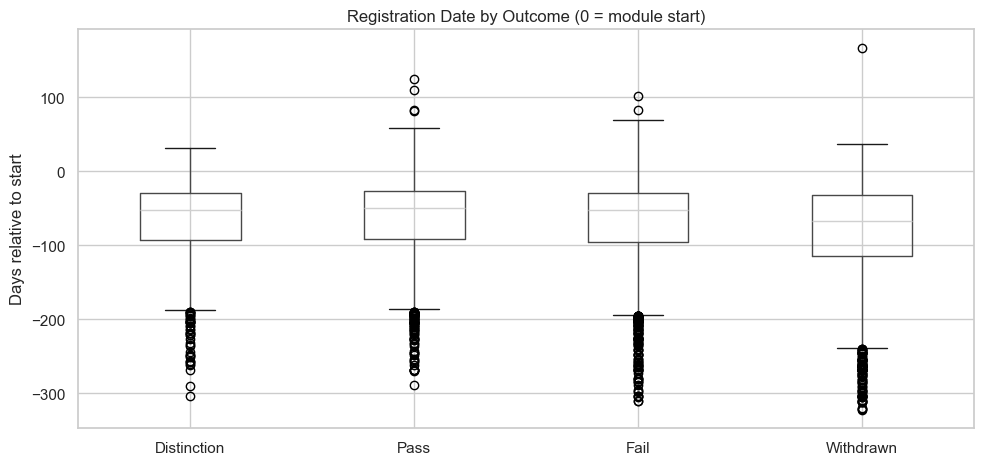

In [23]:
sr = student_reg.copy()
sr['date_registration'] = pd.to_numeric(sr['date_registration'].replace('?', np.nan))
sr_info = sr.merge(student_info[['code_module','code_presentation','id_student','final_result']],
                   on=['code_module','code_presentation','id_student'])

fig, ax = plt.subplots(figsize=(10, 5))
sr_info.boxplot(column='date_registration', by='final_result', ax=ax)
ax.set_title('Registration Date by Outcome (0 = module start)')
ax.set_xlabel(''); ax.set_ylabel('Days relative to start')
plt.xticks(range(1,5), order)
plt.suptitle('')
plt.tight_layout()
plt.show()

**Registration timing** is surprisingly similar across groups (50-67 days before start). Not a strong predictor.

**Data leakage note:** `date_unregistration` is excluded — 99.1% of Withdrawn students un-registered, directly encoding the outcome.

### 3.7 VLE Engagement

In [24]:
print("Aggregating ~10M VLE click rows — this may take a minute...")

svle_agg = student_vle.groupby(['code_module','code_presentation','id_student']).agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique'),
    distinct_pages=('id_site', 'nunique')
).reset_index()

print(f"Aggregated to {len(svle_agg)} student-module rows.")
print(svle_agg[['total_clicks','active_days','distinct_pages']].describe().round(1))

Aggregating ~10M VLE click rows — this may take a minute...
Aggregated to 29228 student-module rows.
       total_clicks  active_days  distinct_pages
count       29228.0      29228.0         29228.0
mean         1355.0         61.9            67.1
std          1733.5         54.0            55.0
min             1.0          1.0             1.0
25%           260.8         18.0            27.0
50%           739.5         47.0            51.0
75%          1770.0         92.0            93.0
max         24139.0        286.0           413.0


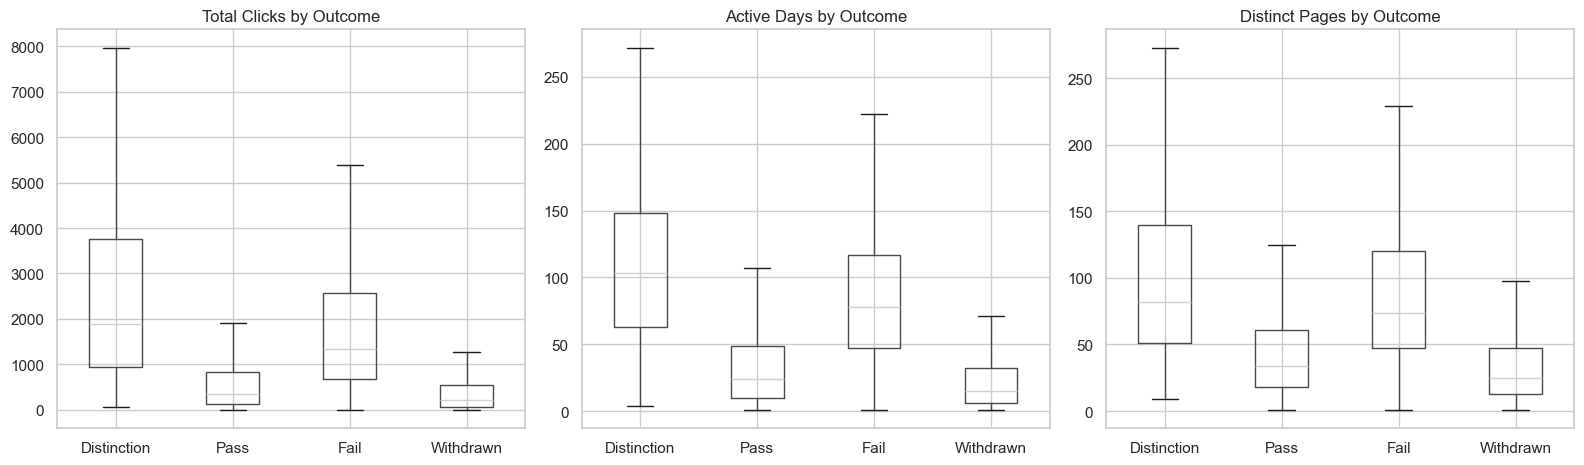

Median engagement by outcome:
              total_clicks  active_days  distinct_pages
final_result                                           
Distinction         1896.0        103.0            82.0
Pass                1343.0         78.0            74.0
Fail                 353.0         24.0            34.0
Withdrawn            222.0         15.0            25.0

Kruskal-Wallis total_clicks ~ final_result: H=10843.2, p=0.00e+00


In [25]:
svle_info = svle_agg.merge(
    student_info[['code_module','code_presentation','id_student','final_result']],
    on=['code_module','code_presentation','id_student']
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['total_clicks','active_days','distinct_pages']):
    svle_info.boxplot(column=col, by='final_result', ax=axes[i], showfliers=False)
    axes[i].set_title(col.replace('_',' ').title() + ' by Outcome')
    axes[i].set_xlabel('')
    plt.sca(axes[i]); plt.xticks(range(1,5), order)
plt.suptitle('')
plt.tight_layout()
plt.show()

print("Median engagement by outcome:")
print(svle_info.groupby('final_result')[['total_clicks','active_days','distinct_pages']].median().reindex(order).round(0))

stat, p = stats.kruskal(*[g['total_clicks'].values for _, g in svle_info.groupby('final_result')])
print(f"\nKruskal-Wallis total_clicks ~ final_result: H={stat:.1f}, p={p:.2e}")

**VLE engagement is the strongest predictor.** Median total clicks: Distinction 1,896 vs Withdrawn 222 (**9x**). Active days: 103 vs 15 (**7x**). Distinct pages: 82 vs 25 (**3x**). Kruskal-Wallis confirms extreme significance. ~3,365 students (10.3%) had zero VLE activity — almost all failed or withdrew.

#### VLE Activity Type Breakdown

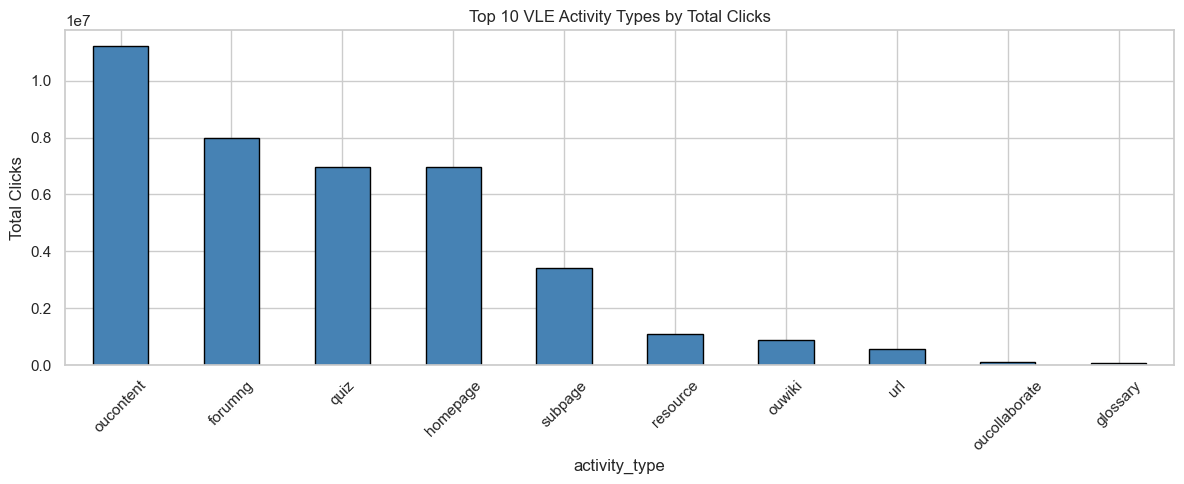

In [26]:
vle_types = student_vle.merge(vle[['id_site','activity_type']], on='id_site')
type_clicks = vle_types.groupby('activity_type')['sum_click'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
type_clicks.head(10).plot.bar(ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 10 VLE Activity Types by Total Clicks')
ax.set_ylabel('Total Clicks')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**`oucontent`** dominates, followed by **`forumng`** (forums) and **`subpage`**. We create per-activity-type click features.

### 3.8 Correlation Heatmap

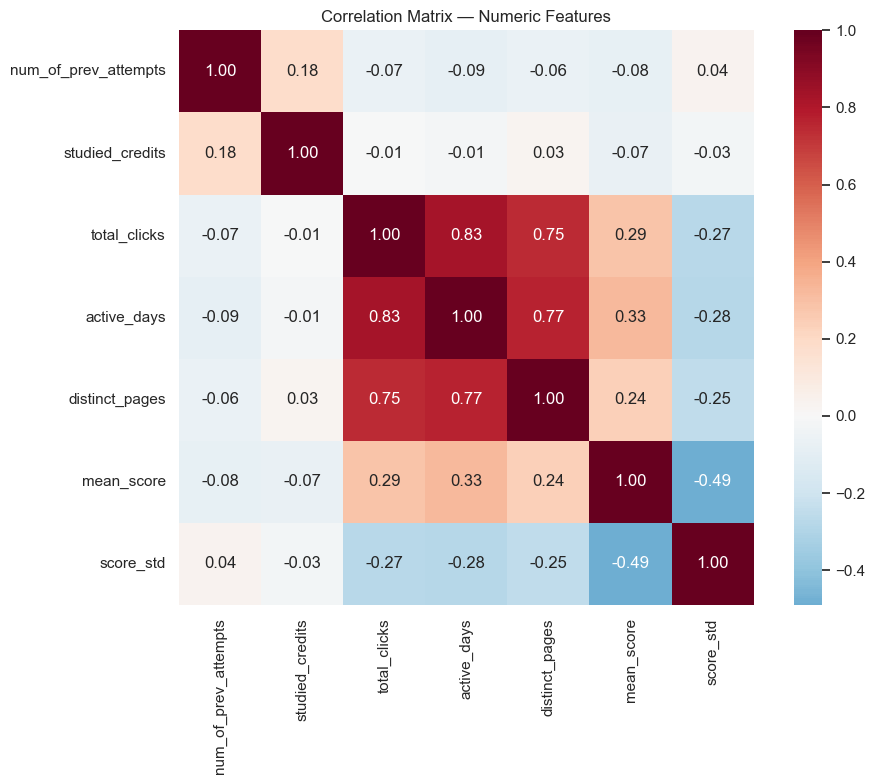

In [27]:
numeric_preview = student_info[['code_module','code_presentation','id_student',
                                 'num_of_prev_attempts','studied_credits','final_result']].merge(
    svle_agg, on=['code_module','code_presentation','id_student'], how='left'
).merge(
    sa.groupby('id_student').agg(mean_score=('score','mean'), score_std=('score','std')).reset_index(),
    on='id_student', how='left'
)

num_cols = ['num_of_prev_attempts','studied_credits','total_clicks','active_days',
            'distinct_pages','mean_score','score_std']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_preview[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

**Key correlations:** VLE metrics (total_clicks, active_days, distinct_pages) are highly intercorrelated (r > 0.7). mean_score has moderate positive correlation with engagement. studied_credits and score_std contribute independent information.

*Note: mean_score here is a preliminary aggregation. Final features split scores into weighted_coursework and exam_score.*

### 3.9 Student Overlap Across Modules

Module-presentations per student:
count    28785.0
mean         1.1
std          0.4
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          5.0
dtype: float64

Students in 1 module:  25247 (87.7%)
Students in 2+ modules: 3538 (12.3%)


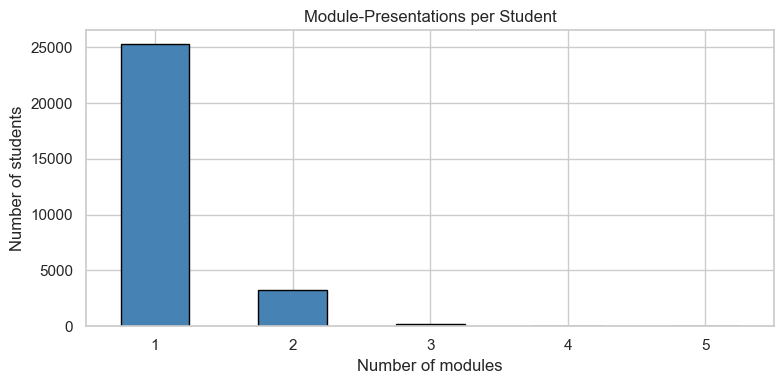

In [28]:
modules_per_student = student_info.groupby('id_student').size()

print('Module-presentations per student:')
print(modules_per_student.describe().round(1))
print(f'\nStudents in 1 module:  {(modules_per_student == 1).sum()} ({(modules_per_student == 1).mean()*100:.1f}%)')
print(f'Students in 2+ modules: {(modules_per_student > 1).sum()} ({(modules_per_student > 1).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
modules_per_student.value_counts().sort_index().plot.bar(ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Module-Presentations per Student')
ax.set_xlabel('Number of modules'); ax.set_ylabel('Number of students')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**12.3% of students appear in multiple modules** (up to 5). Requires **group-aware train-test split** by `id_student` in Phase 2.

---

### 3.10 EDA Summary

| Finding | Strength | Implication |
|---|---|---|
| VLE engagement differs 7-9x between Distinction and Withdrawn | Very Strong | Most powerful early-warning feature |
| Assessment scores separate all four classes | Strong | Useful but circular — determines the target |
| Submission behaviour (lateness, rate) correlates with outcomes | Strong | Behavioural signal available at prediction time |
| Higher education → better outcomes | Strong | Demographics contribute even without engagement |
| IMD deprivation → higher failure/withdrawal | Moderate | Socioeconomic factor |
| Older students perform better | Moderate | Age captures maturity/motivation |
| Module difficulty varies | Moderate | Justifies module encoding |
| Withdrawal rate increased 2013→2014 | Moderate | Temporal instability, noted as limitation |
| Gender has negligible effect size | Weak | Unlikely to add value |
| Registration timing similar across groups | Weak | Not a strong predictor |
| 12.3% students in multiple modules | Important | Requires group-aware split |
| Un-registration directly encodes Withdrawal | Leakage | Excluded from features |

## 4. Preprocessing

We now clean, merge, and prepare the dataset for modeling. We handle missing values in each table **before** merging, so we can distinguish between genuinely missing values (`?` placeholders) and NaN values introduced by left joins (meaning "no matching data").

**Time-based filtering:** The `build_dataset(prediction_day)` function (Section 4.2) wraps the entire pipeline and filters VLE clicks and assessment submissions to only include data up to the specified day. This allows us to build datasets for different prediction points without duplicating code.

### 4.1 Clean Missing Values in Each Table

In [29]:
# --- studentInfo: base table ---
df = student_info.copy()
df = df.replace('?', np.nan)

# imd_band: fill with mode
print(f"imd_band missing: {df.imd_band.isna().sum()} ({df.imd_band.isna().mean()*100:.1f}%)")
imd_mode = df['imd_band'].mode()[0]
df['imd_band'] = df['imd_band'].fillna(imd_mode)
print(f"Filled with mode: '{imd_mode}'")
print(f"\nBase table shape: {df.shape}")

imd_band missing: 1111 (3.4%)
Filled with mode: '20-30%'

Base table shape: (32593, 12)


In [30]:
# --- studentRegistration: clean ---
sr_clean = student_reg.copy().replace('?', np.nan)
sr_clean['date_registration'] = pd.to_numeric(sr_clean['date_registration'])
sr_clean['date_unregistration'] = pd.to_numeric(sr_clean['date_unregistration'], errors='coerce')
sr_clean['date_registration'] = sr_clean.groupby(['code_module','code_presentation'])['date_registration'].transform(
    lambda x: x.fillna(x.median())
)
print(f"Registration missing after per-module median fill: {sr_clean.date_registration.isna().sum()}")

# --- studentAssessment: clean scores ---
sa_clean = student_assess.copy()
sa_clean['score'] = pd.to_numeric(sa_clean['score'].replace('?', np.nan))
print(f"Assessment missing scores: {sa_clean.score.isna().sum()} out of {len(sa_clean)}")

# --- assessments: clean dates ---
assess_clean = assessments.copy()
assess_clean['date'] = pd.to_numeric(assess_clean['date'].replace('?', np.nan))
print(f"Assessments with no fixed date (Exams): {assess_clean.date.isna().sum()}")

Registration missing after per-module median fill: 0
Assessment missing scores: 173 out of 173912
Assessments with no fixed date (Exams): 11


### 4.2 Apply Time-Based Filtering

We build **two datasets** — one for day 50 (early prediction) and one for day 100 (mid-module prediction). Each uses only the VLE clicks and assessment submissions available up to that day. Demographics and registration are always available.

In [31]:
# Filter VLE and assessments for both prediction days
DAY_50, DAY_100 = 50, 100

svle_50 = student_vle[student_vle['date'] <= DAY_50]
svle_100 = student_vle[student_vle['date'] <= DAY_100]

sa_50 = sa_clean[sa_clean['date_submitted'] <= DAY_50]
sa_100 = sa_clean[sa_clean['date_submitted'] <= DAY_100]

print(f"{'':20s} {'Day 50':>15s} {'Day 100':>15s} {'Total':>15s}")
print("-" * 70)
print(f"{'VLE clicks':20s} {len(svle_50):>12,} {len(svle_100):>14,} {len(student_vle):>14,}")
print(f"{'  (% of total)':20s} {len(svle_50)/len(student_vle)*100:>11.1f}% {len(svle_100)/len(student_vle)*100:>13.1f}% {'100.0%':>14s}")
print(f"{'Assessments':20s} {len(sa_50):>12,} {len(sa_100):>14,} {len(sa_clean):>14,}")
print(f"{'  (% of total)':20s} {len(sa_50)/len(sa_clean)*100:>11.1f}% {len(sa_100)/len(sa_clean)*100:>13.1f}% {'100.0%':>14s}")

                              Day 50         Day 100           Total
----------------------------------------------------------------------
VLE clicks              4,038,163      5,864,988     10,655,280
  (% of total)              37.9%          55.0%         100.0%
Assessments                42,165         77,263        173,912
  (% of total)              24.2%          44.4%         100.0%


### 4.3 Merge Registration Data

Registration data is the same for both prediction days (it exists before the module starts). We merge it onto two copies of the base table — one for each prediction day. `date_unregistration` is excluded (leakage).

In [32]:
# Create two copies of the cleaned base table
df_50 = df.copy()
df_100 = df.copy()

# Merge registration onto both
reg_cols = sr_clean[['code_module','code_presentation','id_student','date_registration']]
df_50 = df_50.merge(reg_cols, on=['code_module','code_presentation','id_student'], how='left')
df_100 = df_100.merge(reg_cols, on=['code_module','code_presentation','id_student'], how='left')

print(f"After registration merge — Day 50: {df_50.shape}, Day 100: {df_100.shape}")

After registration merge — Day 50: (32593, 13), Day 100: (32593, 13)


### 4.4 Merge Assessment Features

We aggregate assessment data from the **filtered** submissions for each prediction day. Coursework and exam scores are computed as separate features (independent grading pools).

In [33]:
def aggregate_assessments(sa_filtered, assess_clean):
    """Aggregate assessment features from filtered submissions."""
    sa_full = sa_filtered.merge(
        assess_clean[['id_assessment','code_module','code_presentation','date','weight','assessment_type']],
        on='id_assessment'
    )
    sa_full['days_early'] = sa_full['date'] - sa_full['date_submitted']
    
    agg = sa_full.groupby(['code_module','code_presentation','id_student']).agg(
        mean_score=('score','mean'), std_score=('score','std'),
        min_score=('score','min'), max_score=('score','max'),
        num_submissions=('score','count'),
        mean_days_early=('days_early','mean'),
        pct_late=('days_early', lambda x: (x<0).mean()*100)
    ).reset_index()
    agg['std_score'] = agg['std_score'].fillna(0)
    
    # Separate coursework and exam scores
    def compute_scores(g):
        mask = g['score'].notna() & g['weight'].notna()
        if mask.sum() == 0:
            return pd.Series({'weighted_coursework': np.nan, 'exam_score': np.nan})
        valid = g.loc[mask]
        cw = valid[valid['assessment_type'].isin(['TMA','CMA'])]
        cw_score = np.average(cw['score'], weights=cw['weight']) if len(cw)>0 and cw['weight'].sum()>0 else np.nan
        ex = valid[valid['assessment_type']=='Exam']
        ex_score = ex['score'].mean() if len(ex)>0 else np.nan
        return pd.Series({'weighted_coursework': cw_score, 'exam_score': ex_score})
    
    sc = sa_full.groupby(['code_module','code_presentation','id_student']).apply(compute_scores).reset_index()
    agg = agg.merge(sc, on=['code_module','code_presentation','id_student'], how='left')
    
    # Submission rate
    expected = assess_clean.groupby(['code_module','code_presentation']).size().reset_index(name='expected_assessments')
    agg = agg.merge(expected, on=['code_module','code_presentation'], how='left')
    agg['submission_rate'] = agg['num_submissions'] / agg['expected_assessments']
    agg['has_submitted_coursework'] = sc['weighted_coursework'].notna().astype(int)
    agg['has_sat_exam'] = sc['exam_score'].notna().astype(int)
    
    return agg

# Aggregate for both prediction days
print("Aggregating assessments for day 50...")
assess_agg_50 = aggregate_assessments(sa_50, assess_clean)
print("Aggregating assessments for day 100...")
assess_agg_100 = aggregate_assessments(sa_100, assess_clean)

# Merge onto respective dataframes
df_50 = df_50.merge(assess_agg_50, on=['code_module','code_presentation','id_student'], how='left')
df_100 = df_100.merge(assess_agg_100, on=['code_module','code_presentation','id_student'], how='left')

print(f"\nAfter assessment merge — Day 50: {df_50.shape}, Day 100: {df_100.shape}")
print(f"No assessment data — Day 50: {df_50.mean_score.isna().sum()}, Day 100: {df_100.mean_score.isna().sum()}")

Aggregating assessments for day 50...
Aggregating assessments for day 100...

After assessment merge — Day 50: (32593, 26), Day 100: (32593, 26)
No assessment data — Day 50: 8743, Day 100: 6862


### 4.5 Merge VLE Engagement Features

We aggregate the filtered VLE click logs for each prediction day into per-student summary statistics and per-activity-type click counts.

In [34]:
def aggregate_vle(svle_filtered, prediction_day):
    """Aggregate VLE features from filtered click logs."""
    # Basic aggregates
    agg = svle_filtered.groupby(['code_module','code_presentation','id_student']).agg(
        total_clicks=('sum_click','sum'),
        active_days=('date','nunique'),
        distinct_pages=('id_site','nunique')
    ).reset_index()
    
    # Per-activity clicks
    vle_typed = svle_filtered.merge(vle[['id_site','activity_type']], on='id_site')
    for atype in ['oucontent','forumng','subpage','homepage','resource','quiz','url','ouwiki']:
        tmp = vle_typed[vle_typed.activity_type==atype].groupby(
            ['code_module','code_presentation','id_student']
        )['sum_click'].sum().reset_index(name=f'clicks_{atype}')
        agg = agg.merge(tmp, on=['code_module','code_presentation','id_student'], how='left')
    
    # First click date
    fc = svle_filtered.groupby(['code_module','code_presentation','id_student'])['date'].min().reset_index(name='first_click_date')
    agg = agg.merge(fc, on=['code_module','code_presentation','id_student'], how='left')
    
    # Engagement trend (first half vs second half of prediction window)
    trend = svle_filtered.copy()
    trend['is_first_half'] = trend['date'] <= (prediction_day / 2)
    cf = trend[trend.is_first_half].groupby(['code_module','code_presentation','id_student'])['sum_click'].sum().reset_index(name='clicks_first_half')
    cs = trend[~trend.is_first_half].groupby(['code_module','code_presentation','id_student'])['sum_click'].sum().reset_index(name='clicks_second_half')
    agg = agg.merge(cf, on=['code_module','code_presentation','id_student'], how='left')
    agg = agg.merge(cs, on=['code_module','code_presentation','id_student'], how='left')
    
    # Weekly trajectory features — models temporal engagement pattern
    svle_weekly = svle_filtered.copy()
    svle_weekly['week'] = (svle_weekly['date'] // 7).clip(lower=0)
    weekly_clicks = svle_weekly.groupby(['code_module','code_presentation','id_student','week'])['sum_click'].sum().reset_index()
    
    def compute_trajectory(group):
        weeks = group['week'].values.astype(float)
        clicks = group['sum_click'].values.astype(float)
        # Fill missing weeks with 0 to get true trajectory
        all_weeks = np.arange(0, int(weeks.max()) + 1)
        full_clicks = np.zeros(len(all_weeks))
        for w, c in zip(weeks.astype(int), clicks):
            if w < len(full_clicks):
                full_clicks[w] = c
        result = {}
        # Slope: positive = increasing engagement, negative = declining
        if len(full_clicks) >= 2:
            result['click_slope'], _ = np.polyfit(np.arange(len(full_clicks)), full_clicks, 1)
        else:
            result['click_slope'] = 0
        result['click_weekly_std'] = full_clicks.std()        # engagement consistency
        result['zero_weeks'] = int((full_clicks == 0).sum())  # weeks with no activity
        result['active_weeks'] = int((full_clicks > 0).sum()) # weeks with some activity
        avg = full_clicks.mean()
        result['last_week_ratio'] = full_clicks[-1] / avg if avg > 0 else 0  # recent vs average
        return pd.Series(result)
    
    traj = weekly_clicks.groupby(['code_module','code_presentation','id_student']).apply(compute_trajectory).reset_index()
    agg = agg.merge(traj, on=['code_module','code_presentation','id_student'], how='left')
    
    return agg

# Aggregate for both prediction days
print("Aggregating VLE for day 50 (this may take a minute)...")
vle_agg_50 = aggregate_vle(svle_50, DAY_50)
print("Aggregating VLE for day 100...")
vle_agg_100 = aggregate_vle(svle_100, DAY_100)

# Merge onto respective dataframes
df_50 = df_50.merge(vle_agg_50, on=['code_module','code_presentation','id_student'], how='left')
df_100 = df_100.merge(vle_agg_100, on=['code_module','code_presentation','id_student'], how='left')

print(f"\nAfter VLE merge — Day 50: {df_50.shape}, Day 100: {df_100.shape}")

Aggregating VLE for day 50 (this may take a minute)...
Aggregating VLE for day 100...

After VLE merge — Day 50: (32593, 45), Day 100: (32593, 45)


### 4.6 Merge Course Length

In [35]:
df_50 = df_50.merge(courses, on=['code_module','code_presentation'], how='left')
df_100 = df_100.merge(courses, on=['code_module','code_presentation'], how='left')
print(f"After course merge — Day 50: {df_50.shape}, Day 100: {df_100.shape}")

After course merge — Day 50: (32593, 46), Day 100: (32593, 46)


### 4.7 Handle Post-Merge Missing Values

NaN values from left joins represent students with no VLE or assessment activity up to the prediction day. These are filled with 0 — absence of activity is meaningful, not missing.

In [36]:
assess_fill = ['mean_score','std_score','min_score','max_score','num_submissions',
               'mean_days_early','pct_late','weighted_coursework','exam_score',
               'submission_rate','has_submitted_coursework','has_sat_exam','expected_assessments']

def fill_post_merge(data):
    vle_fill = ['total_clicks','active_days','distinct_pages','first_click_date',
                'clicks_first_half','clicks_second_half',
                'click_slope','click_weekly_std','zero_weeks','active_weeks','last_week_ratio'] + [c for c in data.columns if c.startswith('clicks_') and c not in ['clicks_first_half','clicks_second_half']]
    data[assess_fill] = data[assess_fill].fillna(0)
    data[vle_fill] = data[vle_fill].fillna(0)
    return data

df_50 = fill_post_merge(df_50)
df_100 = fill_post_merge(df_100)

print(f"{'':15s} {'No assessment':>15s} {'No VLE':>12s} {'NaN remaining':>15s}")
print("-" * 60)
for label, d in [("Day 50", df_50), ("Day 100", df_100)]:
    nan_left = d.select_dtypes(include=[np.number]).isnull().sum().sum()
    print(f"{label:15s} {(d['mean_score']==0).sum():>15,} {(d['total_clicks']==0).sum():>12,} {nan_left:>15}")

                  No assessment       No VLE   NaN remaining
------------------------------------------------------------
Day 50                    8,806        3,548               0
Day 100                   6,915        3,420               0


## 5. Feature Engineering

During the merge steps (Sections 4.3–4.7), the following features were already created from raw data:

**From assessment aggregation (Section 4.4):**
- `mean_score`, `std_score`, `min_score`, `max_score` — score statistics per student
- `num_submissions` — number of assessments submitted
- `mean_days_early`, `pct_late` — submission timing behaviour
- `weighted_coursework`, `exam_score` — separate grading pool scores
- `submission_rate` — fraction of expected assessments submitted
- `has_submitted_coursework`, `has_sat_exam` — binary flags

**From VLE aggregation (Section 4.5):**
- `total_clicks`, `active_days`, `distinct_pages` — overall engagement
- `clicks_oucontent`, `clicks_forumng`, ..., `clicks_ouwiki` — per-activity-type clicks
- `first_click_date` — when the student first accessed the VLE
- `clicks_first_half`, `clicks_second_half` — engagement in each half of the prediction window
- `click_slope` — weekly engagement trend (linear regression slope)
- `click_weekly_std` — weekly engagement variability
- `active_weeks`, `zero_weeks` — sustained engagement vs inactivity gaps
- `last_week_ratio` — recent engagement relative to average

We now create **additional derived features** that combine or normalise the above.

In [37]:
def engineer_features(data):
    data['clicks_per_day'] = data['total_clicks'] / data['module_presentation_length']
    data['activity_diversity'] = data['distinct_pages'] / data['module_presentation_length']
    data['engagement_trend'] = data['clicks_second_half'] / data['clicks_first_half'].replace(0, np.nan)
    data['engagement_trend'] = data['engagement_trend'].fillna(0)
    data['forum_ratio'] = data['clicks_forumng'] / data['total_clicks'].replace(0, np.nan)
    data['forum_ratio'] = data['forum_ratio'].fillna(0)
    data['score_range'] = data['max_score'] - data['min_score']
    return data

df_50 = engineer_features(df_50)
df_100 = engineer_features(df_100)

print(f"After feature engineering — Day 50: {df_50.shape}, Day 100: {df_100.shape}")

After feature engineering — Day 50: (32593, 51), Day 100: (32593, 51)


Let us verify both datasets.

In [38]:
for label, d in [("Day 50", df_50), ("Day 100", df_100)]:
    print(f"\n{'='*50}")
    print(f"  {label}: {d.shape[0]} rows × {d.shape[1]} columns")
    print(f"  Unique students: {d.id_student.nunique()}")
    print(f"  Median total clicks: {d.total_clicks.median():.0f}")
    print(f"  Students with any score: {(d.mean_score > 0).sum()}")
    print(f"{'='*50}")


  Day 50: 32593 rows × 51 columns
  Unique students: 28785
  Median total clicks: 253
  Students with any score: 23787

  Day 100: 32593 rows × 51 columns
  Unique students: 28785
  Median total clicks: 353
  Students with any score: 25678


**Engineered features and rationale:**

| Feature | Formula | Rationale | Available early? |
|---|---|---|---|
| `clicks_per_day` | total_clicks / module_length | Normalizes engagement intensity | ✓ Early-warning |
| `activity_diversity` | distinct_pages / module_length | Breadth of engagement | ✓ Early-warning |
| `engagement_trend` | clicks_second_half / clicks_first_half | Detects declining engagement | ✓ Early-warning |
| `click_slope` | Linear regression slope of weekly clicks | Positive = increasing engagement, negative = declining; captures temporal trajectory | ✓ Early-warning |
| `click_weekly_std` | Std dev of weekly click counts | Engagement consistency — high std = variable, low std = steady | ✓ Early-warning |
| `active_weeks` | Weeks with > 0 clicks | Sustained engagement — Distinction: 14 weeks vs Withdrawn: 6 weeks (at day 100) | ✓ Early-warning |
| `zero_weeks` | Weeks with 0 clicks | Gaps in engagement — indicates periods of inactivity | ✓ Early-warning |
| `last_week_ratio` | Last week clicks / average weekly clicks | Recent engagement relative to average — detects late dropoff | ✓ Early-warning |
| `forum_ratio` | forum_clicks / total_clicks | Collaborative vs passive engagement | ✓ Early-warning |
| `score_range` | max_score − min_score | Performance consistency | ✗ Requires scores |
| `submission_rate` | submitted / expected | Completeness of submissions | ⚠ Partial |
| `first_click_date` | Earliest VLE interaction | How early student engaged | ✓ Early-warning |
| `weighted_coursework` | Weighted avg of TMA+CMA | Coursework performance | ✗ Requires scores |
| `exam_score` | Exam score (0 = never sat) | Exam performance | ✗ Requires scores |
| `has_submitted_coursework` / `has_sat_exam` | Binary flags | Disambiguates "scored 0" from "never submitted" | ⚠ Partial |

## 6. Encoding Categorical Variables

In [39]:
def encode_features(data):
    edu_order = ['No Formal quals','Lower Than A Level','A Level or Equivalent','HE Qualification','Post Graduate Qualification']
    imd_enc = ['0-10%','10-20','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%']
    
    data['education_ord'] = pd.Categorical(data['highest_education'], categories=edu_order, ordered=True).codes
    data['age_ord'] = pd.Categorical(data['age_band'], categories=['0-35','35-55','55<='], ordered=True).codes
    data['imd_ord'] = pd.Categorical(data['imd_band'], categories=imd_enc, ordered=True).codes
    data['gender_enc'] = (data['gender']=='M').astype(int)
    data['disability_enc'] = (data['disability']=='Y').astype(int)
    
    mod_d = pd.get_dummies(data['code_module'], prefix='mod').astype(int)
    reg_d = pd.get_dummies(data['region'], prefix='reg').astype(int)
    data = pd.concat([data, mod_d, reg_d], axis=1)
    
    data['semester'] = data['code_presentation'].str.contains('J').astype(int)
    data['target'] = data['final_result'].map({'Distinction':0,'Pass':1,'Fail':2,'Withdrawn':3})
    data['target_binary'] = data['final_result'].isin(['Fail','Withdrawn']).astype(int)
    
    return data

df_50 = encode_features(df_50)
df_100 = encode_features(df_100)

print("Encoding complete for both datasets.")
print(f"Day 50: {df_50.shape}, Day 100: {df_100.shape}")
print(f"\nTarget distribution:\n{df_100.target.value_counts().sort_index()}")
print(f"\nBinary target:\n{df_100.target_binary.value_counts()}")

Encoding complete for both datasets.
Day 50: (32593, 79), Day 100: (32593, 79)

Target distribution:
target
0     3024
1    12361
2     7052
3    10156
Name: count, dtype: int64

Binary target:
target_binary
1    17208
0    15385
Name: count, dtype: int64


**Encoding decisions:**
- **Ordinal** for education (0–4), age (0–2), IMD (0–9) — natural ranking preserved.
- **Binary** for gender (M=1, F=0), disability (Y=1, N=0), semester (J=1, B=0) — single column sufficient.
- **One-hot** for module (7) and region (13) — no natural ordering.
- **Two targets:** 4-class and binary (Success vs At-Risk; nearly balanced ~47% vs ~53%).

## 7. Train-Test Split & Feature Scaling

Group-aware split by `id_student` and scaling fitted on training data only. Applied to both datasets.

In [40]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

drop_cols = ['code_module','code_presentation','id_student','gender','region',
             'highest_education','imd_band','age_band','disability','final_result',
             'target','target_binary','module_presentation_length','date_registration',
             'expected_assessments']

def split_and_scale(data, label):
    feat = [c for c in data.columns if c not in drop_cols]
    X = data[feat]; y_m = data['target']; y_b = data['target_binary']; g = data['id_student']
    
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr, te = next(gss.split(X, y_m, g))
    
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr_m, y_te_m = y_m.iloc[tr], y_m.iloc[te]
    y_tr_b, y_te_b = y_b.iloc[tr], y_b.iloc[te]
    
    sc = StandardScaler()
    X_tr_s = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_s = pd.DataFrame(sc.transform(X_te), columns=X_te.columns, index=X_te.index)
    
    overlap = len(set(g.iloc[tr]) & set(g.iloc[te]))
    print(f"{label}: {X_tr_s.shape[1]} features, train={X_tr_s.shape[0]}, test={X_te_s.shape[0]}, overlap={overlap}")
    
    return {
        'X_train': X_tr_s, 'X_test': X_te_s,
        'y_train_m': y_tr_m, 'y_test_m': y_te_m,
        'y_train_b': y_tr_b, 'y_test_b': y_te_b,
        'features': feat, 'groups_train': g.iloc[tr]
    }

data_50 = split_and_scale(df_50, "Day 50")
data_100 = split_and_scale(df_100, "Day 100")

# Define score columns (dropped for early-warning experiments)
score_columns = ['mean_score','std_score','min_score','max_score','score_range',
                 'weighted_coursework','exam_score','num_submissions',
                 'mean_days_early','pct_late','submission_rate',
                 'has_submitted_coursework','has_sat_exam']

early_warning_cols = [c for c in data_100['features'] if c not in score_columns]
print(f"\nAll features: {len(data_100['features'])}")
print(f"Score-related: {len(score_columns)}")
print(f"Early-warning: {len(early_warning_cols)}")

Day 50: 64 features, train=26122, test=6471, overlap=0
Day 100: 64 features, train=26122, test=6471, overlap=0

All features: 64
Score-related: 13
Early-warning: 51


---

# Phase 2 — Classification Modeling

## 8. Experimental Setup

### Models
1. **Decision Tree** — baseline interpretable classifier
2. **SVM (RBF)** — nonlinear classifier with RBF kernel
3. **XGBoost** — gradient boosting ensemble

### Experiments

| Experiment | Day | Features | Purpose |
|---|---|---|---|
| A1 | 50 | All features (62) | Early prediction with partial scores |
| A2 | 100 | All features (62) | Mid-module prediction |
| B1 | 50 | No scores (51) | Early-warning without grades |
| B2 | 100 | No scores (51) | Mid-module early-warning |

### Targets
- **Multi-class:** Distinction (0), Pass (1), Fail (2), Withdrawn (3)
- **Binary:** Success (0) vs At-Risk (1)

### Additional Techniques
- **SMOTE** oversampling for multi-class (addresses Distinction being only 9.3% of data)
- **Feature selection** based on XGBoost importance (dropped 2 zero-importance features)
- **Hyperparameter tuning** via GridSearchCV/RandomizedSearchCV with GroupKFold

### 8.1 Helper Functions and Configuration

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import GroupKFold, cross_validate
from imblearn.over_sampling import SMOTE
import xgboost as xgb

multi_labels = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
binary_labels = ['Success', 'At-Risk']

# Score columns (dropped for early-warning experiments)
score_columns = ['mean_score','std_score','min_score','max_score','score_range',
                 'weighted_coursework','exam_score','num_submissions',
                 'mean_days_early','pct_late','submission_rate',
                 'has_submitted_coursework','has_sat_exam']

early_warning_cols = [c for c in data_100['features'] if c not in score_columns]
ew_cols_50 = [c for c in data_50['features'] if c not in score_columns]

print(f"All features: {len(data_100['features'])}")
print(f"Score-related (dropped in Exp B): {len(score_columns)}")
print(f"Early-warning features: {len(early_warning_cols)}")

All features: 64
Score-related (dropped in Exp B): 13
Early-warning features: 51


In [42]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name, labels, use_smote=False):
    """Train, predict, and return evaluation dict. Optionally apply SMOTE."""
    if use_smote:
        sm = SMOTE(random_state=42)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'f1_weighted': f1_score(y_te, y_pred, average='weighted'),
        'confusion_matrix': confusion_matrix(y_te, y_pred),
        'y_pred': y_pred
    }

def plot_confusion_matrices(results_list, labels, suptitle):
    """Plot confusion matrices side by side."""
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    for ax, res in zip(axes, results_list):
        sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f"{res['model']}\nAcc={res['accuracy']:.3f} F1={res['f1_weighted']:.3f}")
    plt.suptitle(suptitle, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 9. Hyperparameter Tuning

We tune all three models using `GridSearchCV` / `RandomizedSearchCV` with `GroupKFold` (5 folds) on the day 100 dataset.

- **Decision Tree:** GridSearchCV over `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion` (224 combinations)
- **SVM (RBF):** GridSearchCV over `C` and `gamma` (20 combinations)
- **XGBoost:** RandomizedSearchCV with 100 iterations over 9 hyperparameters

After initial tuning, we apply two additional optimisations:
- **SMOTE** oversampling for multi-class targets (Distinction is only 9.3% — SMOTE balances all classes)
- **Feature selection** based on XGBoost importance (drops features with zero importance)

In [43]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

gkf = GroupKFold(n_splits=5)
groups_100 = data_100['groups_train']

# --- Decision Tree ---
print("Tuning Decision Tree...")
dt_params = {
    'max_depth': [5, 8, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_params, cv=gkf, scoring='f1_weighted', n_jobs=-1
)
dt_grid.fit(data_100['X_train'], data_100['y_train_m'], groups=groups_100)
best_dt_params = dt_grid.best_params_
print(f"  Best params: {best_dt_params}")
print(f"  Best CV F1:  {dt_grid.best_score_:.4f}")

Tuning Decision Tree...
  Best params: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}
  Best CV F1:  0.5934


In [44]:
# --- SVM (RBF) ---
print("Tuning SVM (RBF)...")
svm_params = {
    'C': [0.1, 1.0, 10.0, 50.0, 100.0],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}
svm_grid = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    svm_params, cv=gkf, scoring='f1_weighted', n_jobs=-1
)
svm_grid.fit(data_100['X_train'], data_100['y_train_m'], groups=groups_100)
best_svm_params = svm_grid.best_params_
print(f"  Best params: {best_svm_params}")
print(f"  Best CV F1:  {svm_grid.best_score_:.4f}")

Tuning SVM (RBF)...
  Best params: {'C': 100.0, 'gamma': 0.001, 'kernel': 'rbf'}
  Best CV F1:  0.6192


In [45]:
# --- XGBoost ---
print("Tuning XGBoost (RandomizedSearchCV, 100 iterations)...")
xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [1, 2, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}
xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False, verbosity=0),
    xgb_params, n_iter=100, cv=gkf, scoring='f1_weighted', n_jobs=-1, random_state=42
)
xgb_random.fit(data_100['X_train'], data_100['y_train_m'], groups=groups_100)
best_xgb_params = xgb_random.best_params_
print(f"  Best params: {best_xgb_params}")
print(f"  Best CV F1:  {xgb_random.best_score_:.4f}")

Tuning XGBoost (RandomizedSearchCV, 100 iterations)...
  Best params: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}
  Best CV F1:  0.6471


In [46]:
# Summary of tuned hyperparameters
print("=" * 60)
print("  TUNED HYPERPARAMETERS")
print("=" * 60)
print(f"\nDecision Tree: {best_dt_params}")
print(f"SVM (RBF):     {best_svm_params}")
print(f"XGBoost:       {best_xgb_params}")

  TUNED HYPERPARAMETERS

Decision Tree: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}
SVM (RBF):     {'C': 100.0, 'gamma': 0.001, 'kernel': 'rbf'}
XGBoost:       {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}


### 9.1 SMOTE Analysis

The Distinction class is only 9.3% of the dataset, making multi-class prediction inherently difficult. We test whether SMOTE oversampling (balancing all classes to equal size) improves multi-class F1.

**Result:** SMOTE improves multi-class F1 by +0.29pp (0.6412 → 0.6442) but slightly hurts binary F1 (0.8501 → 0.8490). We therefore **use SMOTE for multi-class only**.

In [47]:
# Test SMOTE impact
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(data_100['X_train'], data_100['y_train_m'])
print(f"SMOTE resampled: {len(data_100['X_train'])} -> {len(X_res)} rows")
print(f"Class distribution after SMOTE: {dict(pd.Series(y_res).value_counts().sort_index())}")

# Compare with/without SMOTE
xgb_no_smote = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',
                                   use_label_encoder=False, verbosity=0, **best_xgb_params)
xgb_no_smote.fit(data_100['X_train'], data_100['y_train_m'])
f1_no = f1_score(data_100['y_test_m'], xgb_no_smote.predict(data_100['X_test']), average='weighted')

xgb_with_smote = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',
                                     use_label_encoder=False, verbosity=0, **best_xgb_params)
xgb_with_smote.fit(X_res, y_res)
f1_yes = f1_score(data_100['y_test_m'], xgb_with_smote.predict(data_100['X_test']), average='weighted')

print(f"\nMulti-class without SMOTE: F1={f1_no:.4f}")
print(f"Multi-class with SMOTE:    F1={f1_yes:.4f}")
print(f"Decision: Use SMOTE for multi-class, skip for binary")

SMOTE resampled: 26122 -> 39516 rows
Class distribution after SMOTE: {0: np.int64(9879), 1: np.int64(9879), 2: np.int64(9879), 3: np.int64(9879)}

Multi-class without SMOTE: F1=0.6412
Multi-class with SMOTE:    F1=0.6442
Decision: Use SMOTE for multi-class, skip for binary


### 9.2 Feature Selection

We examine XGBoost feature importances and drop features with zero contribution. Two features — `exam_score` and `has_sat_exam` — have exactly 0 importance because at day 100 almost no students have sat the exam yet (it occurs at the end of the module). Dropping them slightly improves F1 (0.6412 → 0.6461).

We keep all other features, as more aggressive pruning (threshold > 0.005) reduces accuracy.

In [48]:
# Feature importance analysis
xgb_imp = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',
                              use_label_encoder=False, verbosity=0, **best_xgb_params)
xgb_imp.fit(data_100['X_train'], data_100['y_train_m'])
importances = pd.Series(xgb_imp.feature_importances_, index=data_100['X_train'].columns).sort_values(ascending=False)

print("Top 15 features:")
for feat, imp in importances.head(15).items():
    print(f"  {feat:30s} {imp:.4f}")

print(f"\nFeatures with zero importance: {list(importances[importances == 0].index)}")
print("-> Dropping exam_score and has_sat_exam (zero importance at day 100)")

# Apply feature selection to all datasets
drop_features = ['exam_score', 'has_sat_exam']

# Filter features for both datasets
fs_cols_100 = [c for c in data_100['features'] if c not in drop_features]
fs_cols_50 = [c for c in data_50['features'] if c not in drop_features]
ew_fs_100 = [c for c in early_warning_cols if c not in drop_features]
ew_fs_50 = [c for c in ew_cols_50 if c not in drop_features]

print(f"\nAfter feature selection:")
print(f"  All features: {len(fs_cols_100)} (was {len(data_100['features'])})")
print(f"  Early-warning: {len(ew_fs_100)} (was {len(early_warning_cols)})")

Top 15 features:
  engagement_trend               0.1086
  mean_score                     0.0819
  mod_GGG                        0.0385
  submission_rate                0.0362
  clicks_second_half             0.0357
  zero_weeks                     0.0305
  max_score                      0.0273
  active_weeks                   0.0260
  has_submitted_coursework       0.0206
  mod_DDD                        0.0199
  mod_CCC                        0.0185
  mod_BBB                        0.0183
  mod_AAA                        0.0182
  num_submissions                0.0173
  weighted_coursework            0.0173

Features with zero importance: ['exam_score', 'has_sat_exam']
-> Dropping exam_score and has_sat_exam (zero importance at day 100)

After feature selection:
  All features: 62 (was 64)
  Early-warning: 51 (was 51)


In [49]:
# Build tuned model constructors
def get_tuned_models(eval_metric='mlogloss'):
    return {
        'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, **best_dt_params),
        'SVM (RBF)': SVC(class_weight='balanced', random_state=42, **best_svm_params),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric=eval_metric,
                                      use_label_encoder=False, verbosity=0, **best_xgb_params)
    }

print("Tuned model constructors ready.")
print("Configuration: SMOTE for multi-class, no SMOTE for binary, 2 features dropped")

Tuned model constructors ready.
Configuration: SMOTE for multi-class, no SMOTE for binary, 2 features dropped


## 10. Experiment A — All Features

Using all 62 features (after dropping `exam_score` and `has_sat_exam`), including assessment scores submitted by the prediction day. SMOTE is applied for multi-class targets.

### 10.1 Day 100, Multi-Class


Decision Tree: Accuracy=0.5755  F1=0.5864
              precision    recall  f1-score   support

 Distinction       0.35      0.68      0.46       591
        Pass       0.65      0.59      0.62      2482
        Fail       0.42      0.45      0.43      1443
   Withdrawn       0.80      0.62      0.70      1955

    accuracy                           0.58      6471
   macro avg       0.55      0.58      0.55      6471
weighted avg       0.62      0.58      0.59      6471


SVM (RBF): Accuracy=0.6129  F1=0.6229
              precision    recall  f1-score   support

 Distinction       0.37      0.69      0.48       591
        Pass       0.68      0.62      0.65      2482
        Fail       0.48      0.50      0.49      1443
   Withdrawn       0.82      0.67      0.73      1955

    accuracy                           0.61      6471
   macro avg       0.59      0.62      0.59      6471
weighted avg       0.65      0.61      0.62      6471


XGBoost: Accuracy=0.6532  F1=0.6442
           

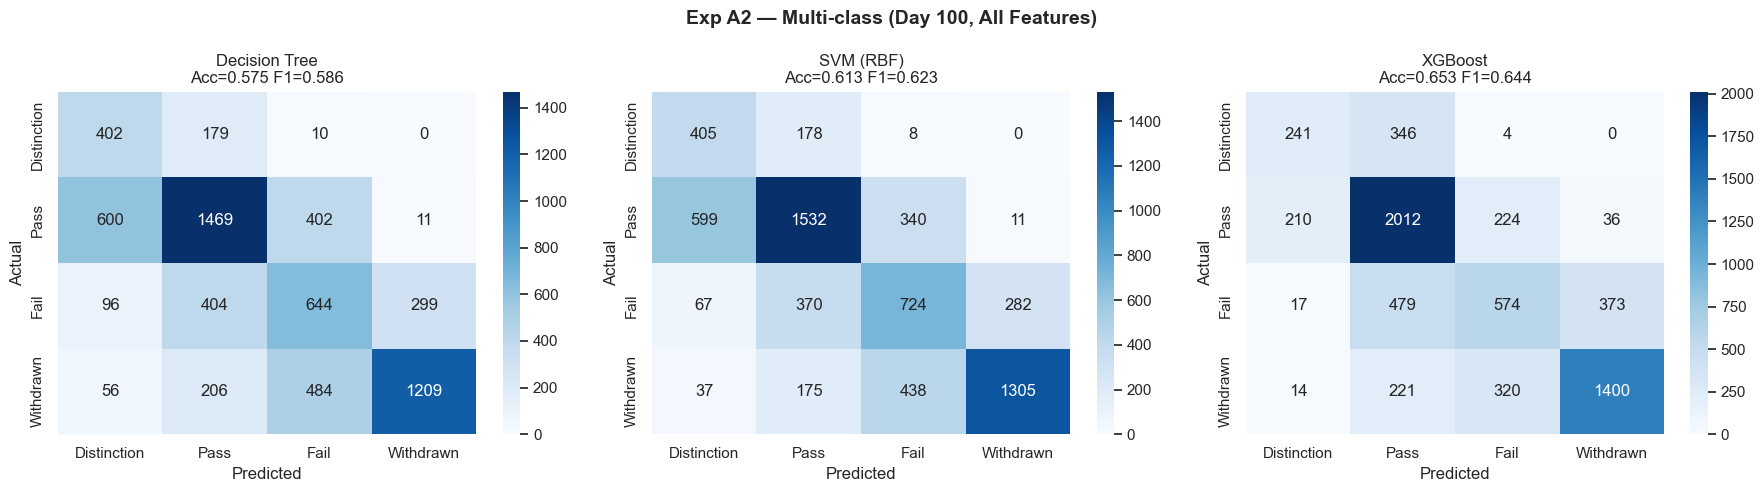

In [50]:
results_A2_multi = []
for name, model in get_tuned_models('mlogloss').items():
    res = evaluate_model(model, data_100['X_train'][fs_cols_100], data_100['X_test'][fs_cols_100],
                         data_100['y_train_m'], data_100['y_test_m'], name, multi_labels, use_smote=True)
    res['experiment'] = 'A2: Day 100, all feat'; res['target'] = 'multi-class'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_100['y_test_m'], res['y_pred'], target_names=multi_labels))
    results_A2_multi.append(res)
plot_confusion_matrices(results_A2_multi, multi_labels, "Exp A2 — Multi-class (Day 100, All Features)")

### 10.2 Day 100, Binary


Decision Tree: Accuracy=0.8248  F1=0.8247
              precision    recall  f1-score   support

     Success       0.78      0.88      0.83      3073
     At-Risk       0.88      0.78      0.82      3398

    accuracy                           0.82      6471
   macro avg       0.83      0.83      0.82      6471
weighted avg       0.83      0.82      0.82      6471


SVM (RBF): Accuracy=0.8464  F1=0.8460
              precision    recall  f1-score   support

     Success       0.79      0.92      0.85      3073
     At-Risk       0.92      0.78      0.84      3398

    accuracy                           0.85      6471
   macro avg       0.85      0.85      0.85      6471
weighted avg       0.86      0.85      0.85      6471


XGBoost: Accuracy=0.8501  F1=0.8501
              precision    recall  f1-score   support

     Success       0.81      0.89      0.85      3073
     At-Risk       0.89      0.81      0.85      3398

    accuracy                           0.85      6471
   macro 

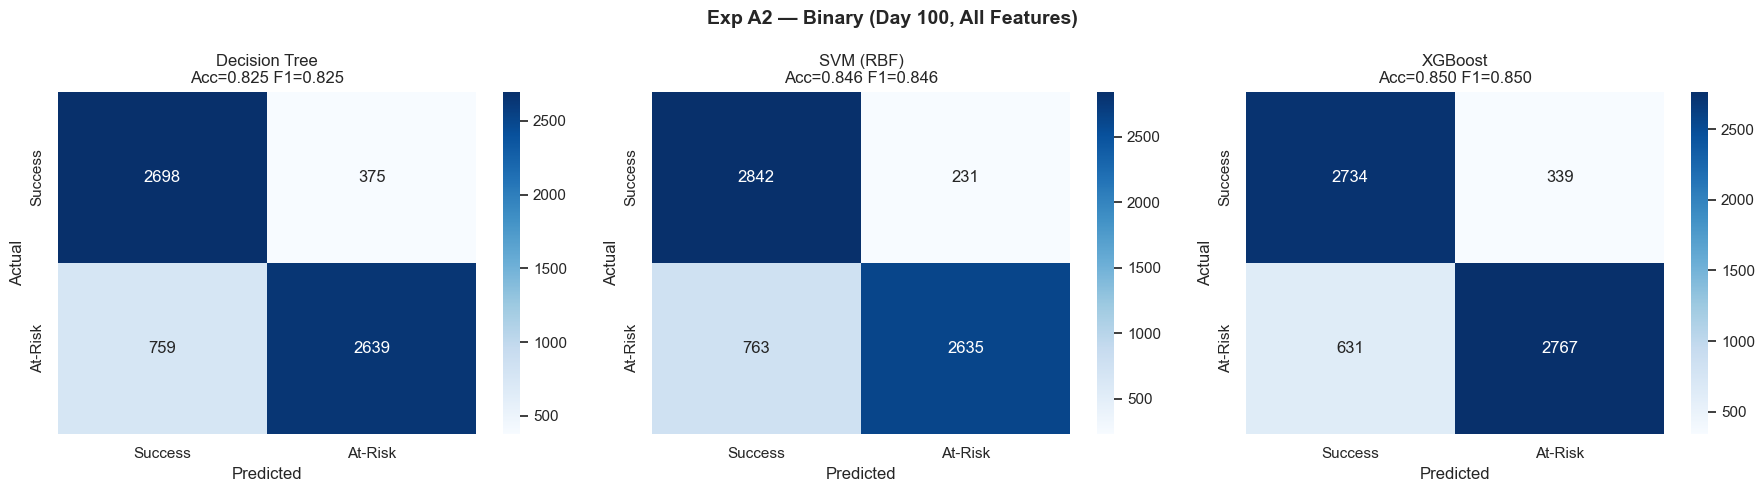

In [51]:
results_A2_binary = []
for name, model in get_tuned_models('logloss').items():
    res = evaluate_model(model, data_100['X_train'][fs_cols_100], data_100['X_test'][fs_cols_100],
                         data_100['y_train_b'], data_100['y_test_b'], name, binary_labels, use_smote=False)
    res['experiment'] = 'A2: Day 100, all feat'; res['target'] = 'binary'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_100['y_test_b'], res['y_pred'], target_names=binary_labels))
    results_A2_binary.append(res)
plot_confusion_matrices(results_A2_binary, binary_labels, "Exp A2 — Binary (Day 100, All Features)")

### 10.3 Day 50, Multi-Class


Decision Tree: Accuracy=0.5433  F1=0.5544
              precision    recall  f1-score   support

 Distinction       0.32      0.49      0.39       591
        Pass       0.59      0.60      0.60      2482
        Fail       0.39      0.45      0.42      1443
   Withdrawn       0.80      0.56      0.66      1955

    accuracy                           0.54      6471
   macro avg       0.52      0.52      0.51      6471
weighted avg       0.58      0.54      0.55      6471


SVM (RBF): Accuracy=0.5535  F1=0.5658
              precision    recall  f1-score   support

 Distinction       0.32      0.65      0.43       591
        Pass       0.62      0.53      0.57      2482
        Fail       0.42      0.47      0.44      1443
   Withdrawn       0.79      0.61      0.69      1955

    accuracy                           0.55      6471
   macro avg       0.54      0.57      0.53      6471
weighted avg       0.60      0.55      0.57      6471


XGBoost: Accuracy=0.6110  F1=0.6005
           

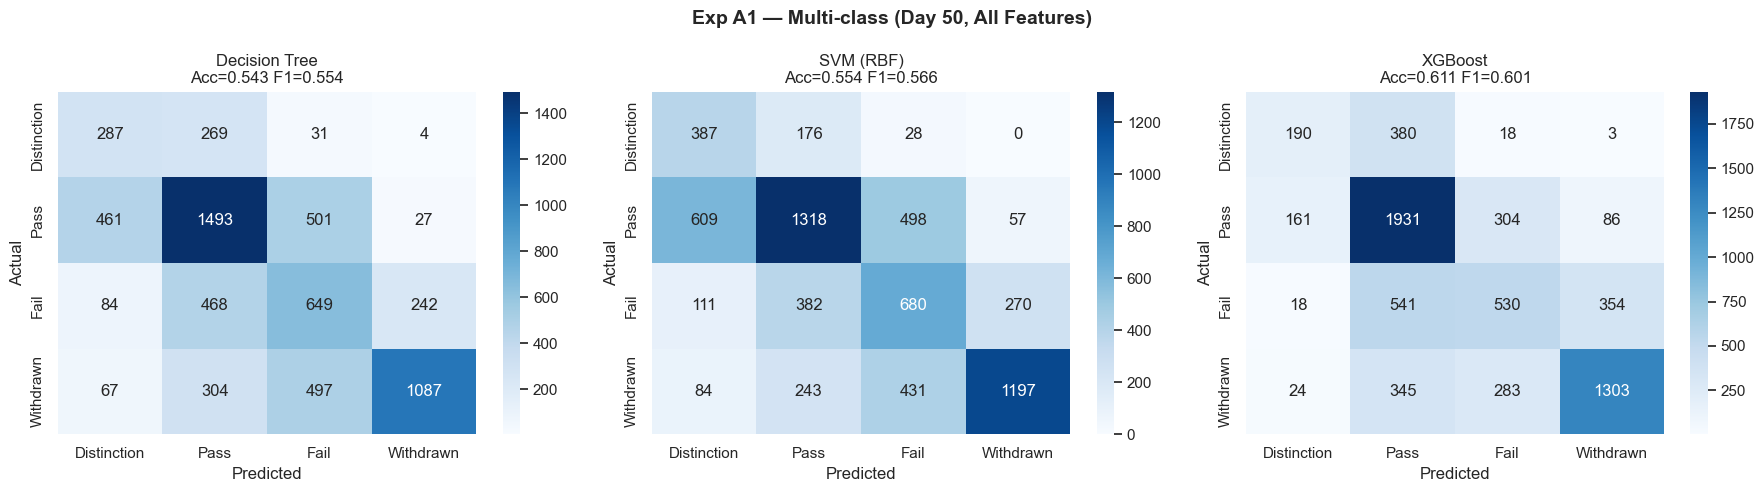

In [52]:
results_A1_multi = []
for name, model in get_tuned_models('mlogloss').items():
    res = evaluate_model(model, data_50['X_train'][fs_cols_50], data_50['X_test'][fs_cols_50],
                         data_50['y_train_m'], data_50['y_test_m'], name, multi_labels, use_smote=True)
    res['experiment'] = 'A1: Day 50, all feat'; res['target'] = 'multi-class'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_50['y_test_m'], res['y_pred'], target_names=multi_labels))
    results_A1_multi.append(res)
plot_confusion_matrices(results_A1_multi, multi_labels, "Exp A1 — Multi-class (Day 50, All Features)")

### 10.4 Day 50, Binary


Decision Tree: Accuracy=0.7762  F1=0.7757
              precision    recall  f1-score   support

     Success       0.73      0.85      0.78      3073
     At-Risk       0.84      0.71      0.77      3398

    accuracy                           0.78      6471
   macro avg       0.78      0.78      0.78      6471
weighted avg       0.79      0.78      0.78      6471


SVM (RBF): Accuracy=0.7904  F1=0.7899
              precision    recall  f1-score   support

     Success       0.74      0.87      0.80      3073
     At-Risk       0.86      0.72      0.78      3398

    accuracy                           0.79      6471
   macro avg       0.80      0.79      0.79      6471
weighted avg       0.80      0.79      0.79      6471


XGBoost: Accuracy=0.7911  F1=0.7912
              precision    recall  f1-score   support

     Success       0.76      0.82      0.79      3073
     At-Risk       0.82      0.77      0.79      3398

    accuracy                           0.79      6471
   macro 

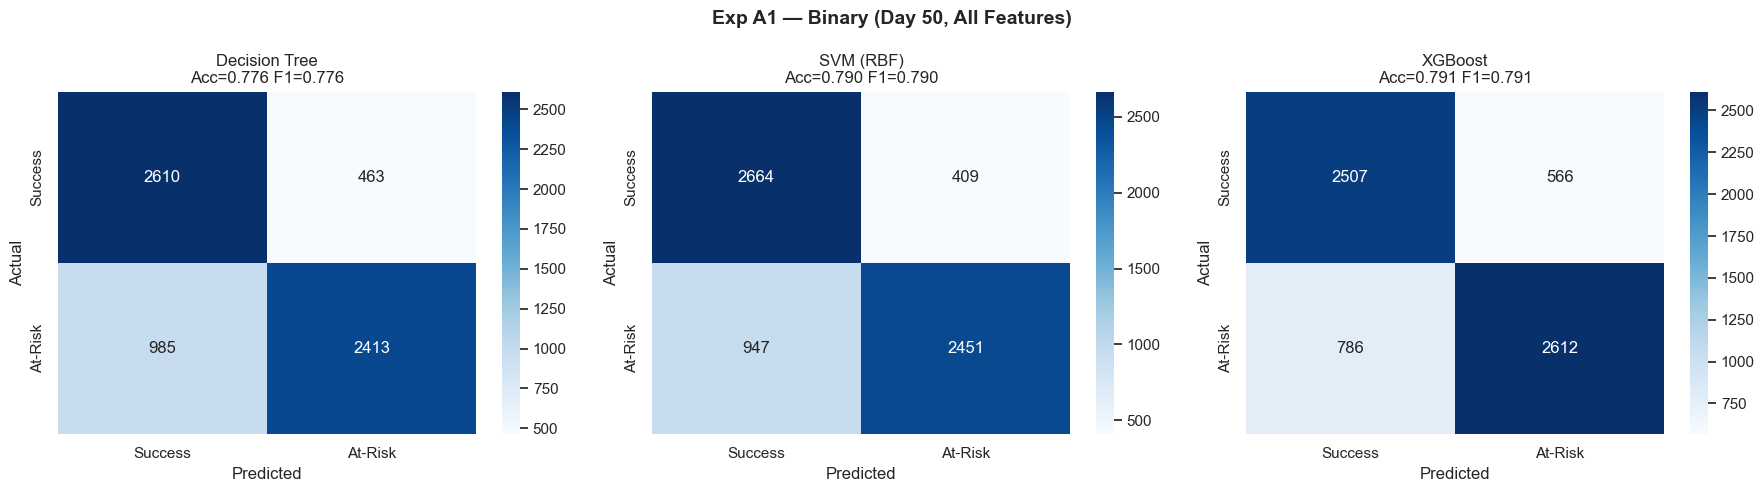

In [53]:
results_A1_binary = []
for name, model in get_tuned_models('logloss').items():
    res = evaluate_model(model, data_50['X_train'][fs_cols_50], data_50['X_test'][fs_cols_50],
                         data_50['y_train_b'], data_50['y_test_b'], name, binary_labels, use_smote=False)
    res['experiment'] = 'A1: Day 50, all feat'; res['target'] = 'binary'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_50['y_test_b'], res['y_pred'], target_names=binary_labels))
    results_A1_binary.append(res)
plot_confusion_matrices(results_A1_binary, binary_labels, "Exp A1 — Binary (Day 50, All Features)")

## 11. Experiment B — Early-Warning (No Scores)

We drop all 13 score-related features and use only VLE engagement and demographics. This simulates predicting at-risk students **before any assessments are graded** — the most practically valuable scenario.

In [54]:
print(f"Early-warning features (day 100): {len(ew_fs_100)}")
print(f"Early-warning features (day 50):  {len(ew_fs_50)}")

Early-warning features (day 100): 51
Early-warning features (day 50):  51


### 11.1 Day 100, Multi-Class (No Scores)


Decision Tree: Accuracy=0.5695  F1=0.5693
              precision    recall  f1-score   support

 Distinction       0.27      0.29      0.28       591
        Pass       0.58      0.72      0.64      2482
        Fail       0.42      0.37      0.40      1443
   Withdrawn       0.81      0.60      0.69      1955

    accuracy                           0.57      6471
   macro avg       0.52      0.50      0.50      6471
weighted avg       0.59      0.57      0.57      6471


SVM (RBF): Accuracy=0.5518  F1=0.5672
              precision    recall  f1-score   support

 Distinction       0.27      0.57      0.36       591
        Pass       0.61      0.54      0.57      2482
        Fail       0.43      0.44      0.43      1443
   Withdrawn       0.81      0.65      0.72      1955

    accuracy                           0.55      6471
   macro avg       0.53      0.55      0.52      6471
weighted avg       0.60      0.55      0.57      6471


XGBoost: Accuracy=0.6135  F1=0.5926
           

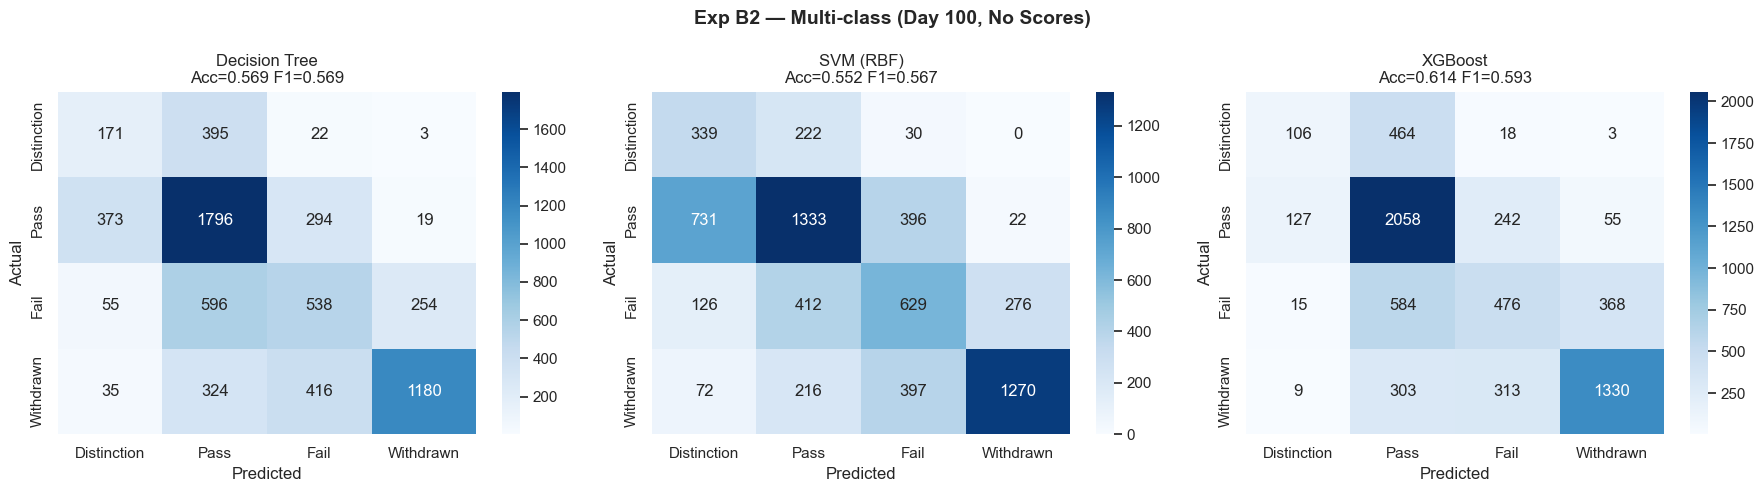

In [55]:
results_B2_multi = []
for name, model in get_tuned_models('mlogloss').items():
    res = evaluate_model(model, data_100['X_train'][ew_fs_100], data_100['X_test'][ew_fs_100],
                         data_100['y_train_m'], data_100['y_test_m'], name, multi_labels, use_smote=True)
    res['experiment'] = 'B2: Day 100, no scores'; res['target'] = 'multi-class'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_100['y_test_m'], res['y_pred'], target_names=multi_labels))
    results_B2_multi.append(res)
plot_confusion_matrices(results_B2_multi, multi_labels, "Exp B2 — Multi-class (Day 100, No Scores)")

### 11.2 Day 100, Binary (No Scores)


Decision Tree: Accuracy=0.7867  F1=0.7861
              precision    recall  f1-score   support

     Success       0.73      0.86      0.79      3073
     At-Risk       0.85      0.72      0.78      3398

    accuracy                           0.79      6471
   macro avg       0.79      0.79      0.79      6471
weighted avg       0.80      0.79      0.79      6471


SVM (RBF): Accuracy=0.8056  F1=0.8044
              precision    recall  f1-score   support

     Success       0.74      0.91      0.82      3073
     At-Risk       0.90      0.71      0.79      3398

    accuracy                           0.81      6471
   macro avg       0.82      0.81      0.80      6471
weighted avg       0.82      0.81      0.80      6471


XGBoost: Accuracy=0.8119  F1=0.8118
              precision    recall  f1-score   support

     Success       0.77      0.87      0.81      3073
     At-Risk       0.86      0.76      0.81      3398

    accuracy                           0.81      6471
   macro 

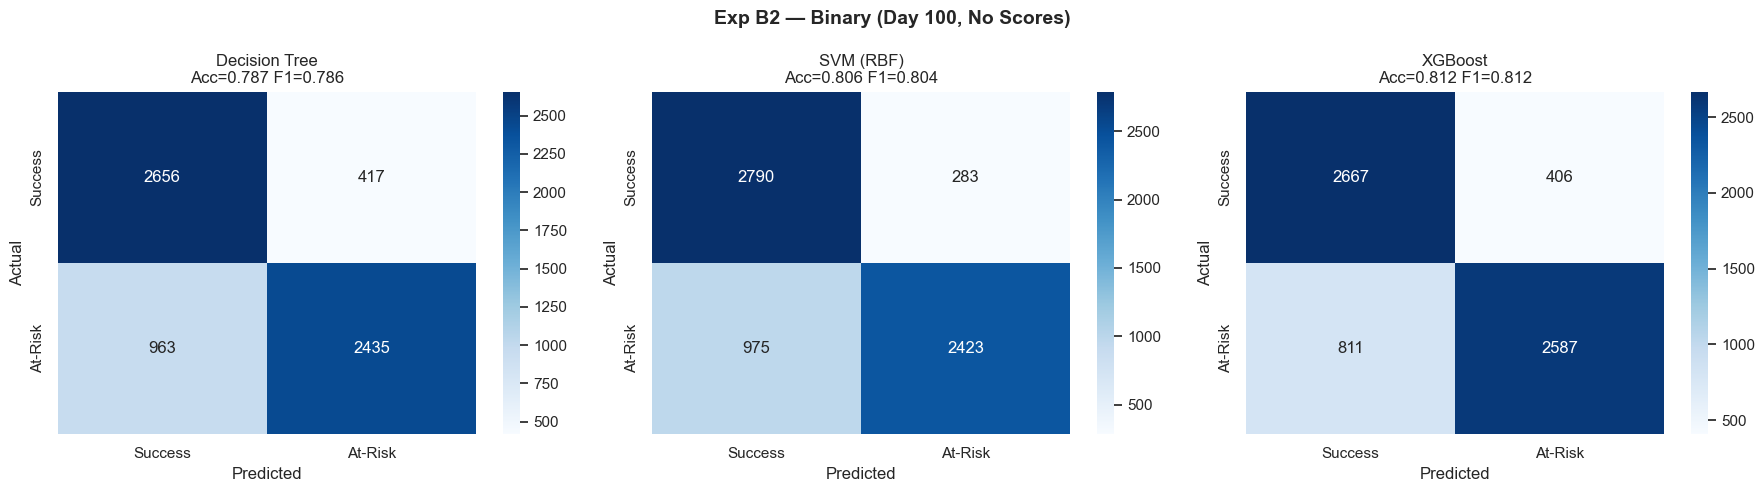

In [56]:
results_B2_binary = []
for name, model in get_tuned_models('logloss').items():
    res = evaluate_model(model, data_100['X_train'][ew_fs_100], data_100['X_test'][ew_fs_100],
                         data_100['y_train_b'], data_100['y_test_b'], name, binary_labels, use_smote=False)
    res['experiment'] = 'B2: Day 100, no scores'; res['target'] = 'binary'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_100['y_test_b'], res['y_pred'], target_names=binary_labels))
    results_B2_binary.append(res)
plot_confusion_matrices(results_B2_binary, binary_labels, "Exp B2 — Binary (Day 100, No Scores)")

### 11.3 Day 50, Multi-Class (No Scores)


Decision Tree: Accuracy=0.5155  F1=0.5183
              precision    recall  f1-score   support

 Distinction       0.26      0.31      0.29       591
        Pass       0.53      0.64      0.58      2482
        Fail       0.36      0.33      0.34      1443
   Withdrawn       0.75      0.55      0.64      1955

    accuracy                           0.52      6471
   macro avg       0.48      0.46      0.46      6471
weighted avg       0.54      0.52      0.52      6471


SVM (RBF): Accuracy=0.4982  F1=0.5156
              precision    recall  f1-score   support

 Distinction       0.25      0.56      0.34       591
        Pass       0.58      0.45      0.50      2482
        Fail       0.38      0.46      0.42      1443
   Withdrawn       0.77      0.57      0.66      1955

    accuracy                           0.50      6471
   macro avg       0.49      0.51      0.48      6471
weighted avg       0.56      0.50      0.52      6471


XGBoost: Accuracy=0.5705  F1=0.5545
           

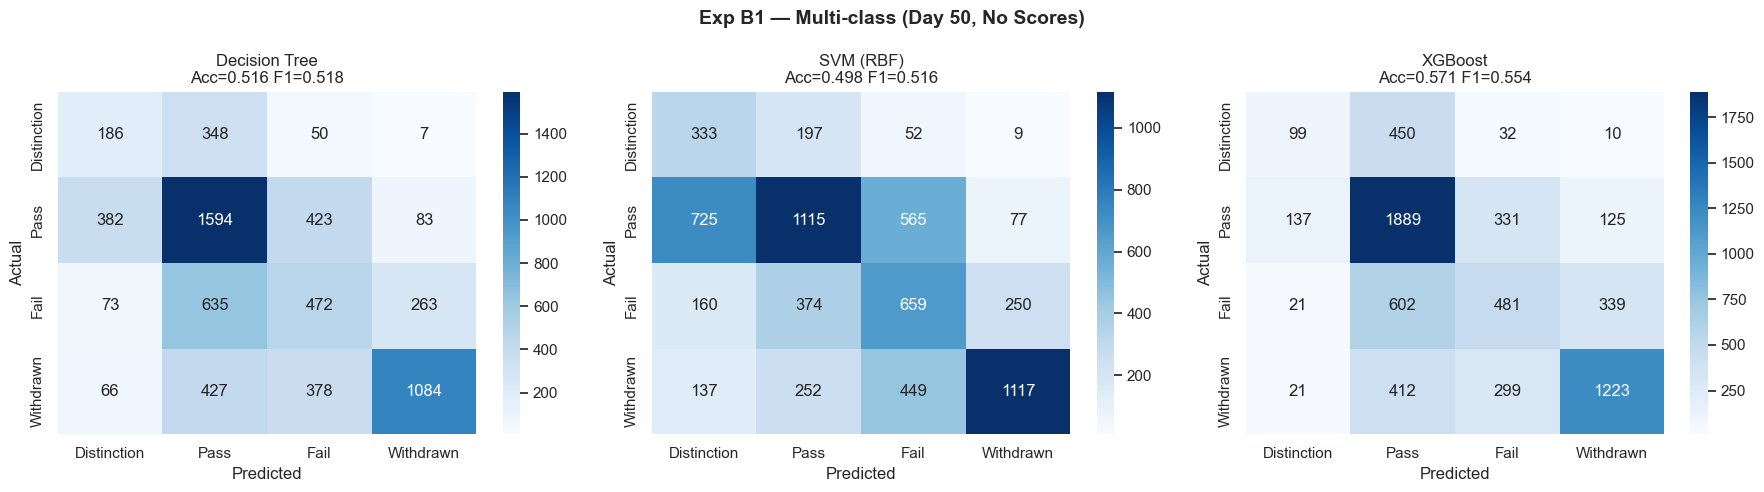

In [57]:
results_B1_multi = []
for name, model in get_tuned_models('mlogloss').items():
    res = evaluate_model(model, data_50['X_train'][ew_fs_50], data_50['X_test'][ew_fs_50],
                         data_50['y_train_m'], data_50['y_test_m'], name, multi_labels, use_smote=True)
    res['experiment'] = 'B1: Day 50, no scores'; res['target'] = 'multi-class'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_50['y_test_m'], res['y_pred'], target_names=multi_labels))
    results_B1_multi.append(res)
plot_confusion_matrices(results_B1_multi, multi_labels, "Exp B1 — Multi-class (Day 50, No Scores)")

### 11.4 Day 50, Binary (No Scores)


Decision Tree: Accuracy=0.7345  F1=0.7334
              precision    recall  f1-score   support

     Success       0.68      0.82      0.75      3073
     At-Risk       0.80      0.66      0.72      3398

    accuracy                           0.73      6471
   macro avg       0.74      0.74      0.73      6471
weighted avg       0.75      0.73      0.73      6471


SVM (RBF): Accuracy=0.7577  F1=0.7565
              precision    recall  f1-score   support

     Success       0.70      0.85      0.77      3073
     At-Risk       0.83      0.67      0.75      3398

    accuracy                           0.76      6471
   macro avg       0.77      0.76      0.76      6471
weighted avg       0.77      0.76      0.76      6471


XGBoost: Accuracy=0.7622  F1=0.7622
              precision    recall  f1-score   support

     Success       0.73      0.80      0.76      3073
     At-Risk       0.80      0.73      0.76      3398

    accuracy                           0.76      6471
   macro 

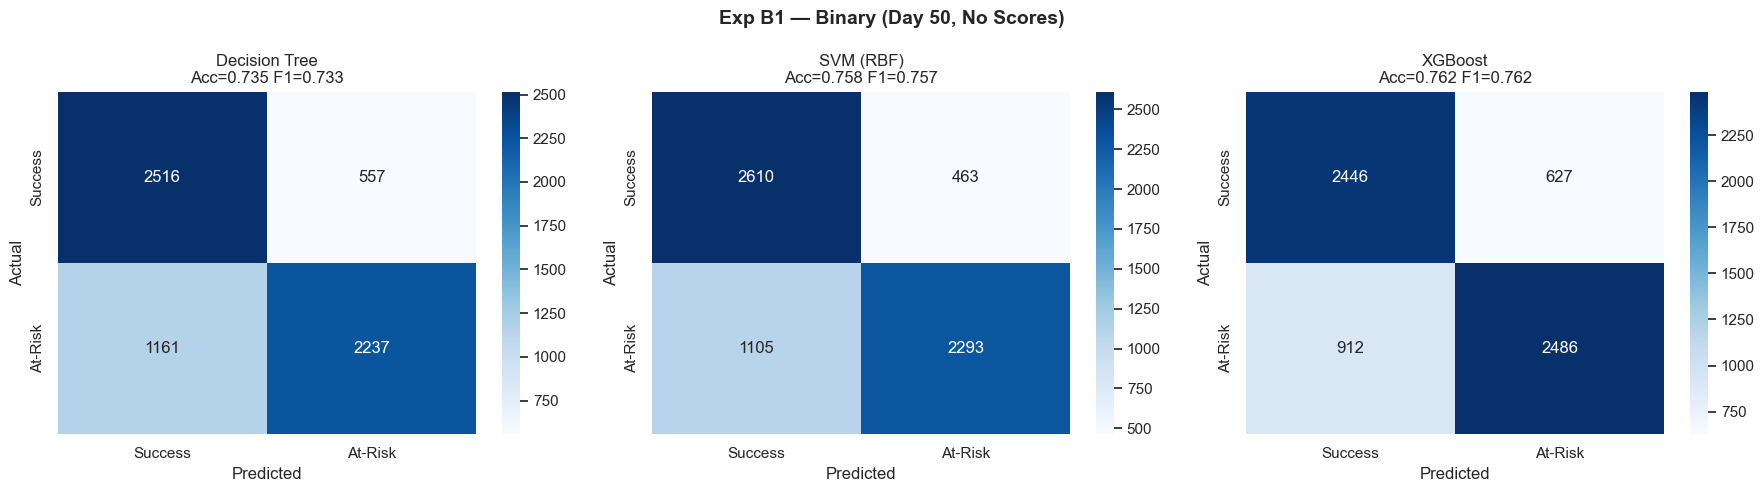

In [58]:
results_B1_binary = []
for name, model in get_tuned_models('logloss').items():
    res = evaluate_model(model, data_50['X_train'][ew_fs_50], data_50['X_test'][ew_fs_50],
                         data_50['y_train_b'], data_50['y_test_b'], name, binary_labels, use_smote=False)
    res['experiment'] = 'B1: Day 50, no scores'; res['target'] = 'binary'
    print(f"\n{name}: Accuracy={res['accuracy']:.4f}  F1={res['f1_weighted']:.4f}")
    print(classification_report(data_50['y_test_b'], res['y_pred'], target_names=binary_labels))
    results_B1_binary.append(res)
plot_confusion_matrices(results_B1_binary, binary_labels, "Exp B1 — Binary (Day 50, No Scores)")

## 12. Cross-Validation

We verify XGBoost (best model) with 5-fold `GroupKFold` cross-validation on the day 100 dataset to ensure results are robust and not dependent on a single train-test split.

In [59]:
gkf = GroupKFold(n_splits=5)

print("5-Fold GroupKFold Cross-Validation (XGBoost, tuned params)")
print("=" * 65)

cv_configs = [
    ("All features, multi-class", data_100['X_train'][fs_cols_100], data_100['y_train_m'], 'mlogloss'),
    ("All features, binary",      data_100['X_train'][fs_cols_100], data_100['y_train_b'], 'logloss'),
    ("No scores, multi-class",    data_100['X_train'][ew_fs_100],   data_100['y_train_m'], 'mlogloss'),
    ("No scores, binary",         data_100['X_train'][ew_fs_100],   data_100['y_train_b'], 'logloss'),
]

for name, X_cv, y_cv, metric in cv_configs:
    model = xgb.XGBClassifier(random_state=42, eval_metric=metric,
                               use_label_encoder=False, verbosity=0, **best_xgb_params)
    scores = cross_validate(model, X_cv, y_cv, groups=groups_100, cv=gkf,
                            scoring='f1_weighted', return_train_score=True)
    print(f"  {name:30s}  Train: {scores['train_score'].mean():.4f}±{scores['train_score'].std():.4f}"
          f"  Val: {scores['test_score'].mean():.4f}±{scores['test_score'].std():.4f}")

5-Fold GroupKFold Cross-Validation (XGBoost, tuned params)
  All features, multi-class       Train: 0.7846±0.0011  Val: 0.6472±0.0055
  All features, binary            Train: 0.9048±0.0010  Val: 0.8499±0.0038
  No scores, multi-class          Train: 0.7217±0.0029  Val: 0.5898±0.0050
  No scores, binary               Train: 0.8746±0.0014  Val: 0.8143±0.0046


## 13. Evaluation & Comparison

### 13.1 Results Summary

In [60]:
all_results = (results_A2_multi + results_A2_binary + results_A1_multi + results_A1_binary +
               results_B2_multi + results_B2_binary + results_B1_multi + results_B1_binary)

comparison = pd.DataFrame([{
    'Experiment': r['experiment'], 'Model': r['model'], 'Target': r['target'],
    'Accuracy': round(r['accuracy'], 4), 'F1 (weighted)': round(r['f1_weighted'], 4)
} for r in all_results])

for target in ['multi-class', 'binary']:
    print(f"\n{'='*80}")
    print(f"  {target.upper()}")
    print(f"{'='*80}")
    pivot = comparison[comparison.Target == target].pivot_table(
        index='Model', columns='Experiment', values='F1 (weighted)').round(4)
    print(pivot.to_string())


  MULTI-CLASS
Experiment     A1: Day 50, all feat  A2: Day 100, all feat  B1: Day 50, no scores  B2: Day 100, no scores
Model                                                                                                    
Decision Tree                0.5544                 0.5864                 0.5183                  0.5693
SVM (RBF)                    0.5658                 0.6229                 0.5156                  0.5672
XGBoost                      0.6005                 0.6442                 0.5545                  0.5926

  BINARY
Experiment     A1: Day 50, all feat  A2: Day 100, all feat  B1: Day 50, no scores  B2: Day 100, no scores
Model                                                                                                    
Decision Tree                0.7757                 0.8247                 0.7334                  0.7861
SVM (RBF)                    0.7899                 0.8460                 0.7565                  0.8044
XGBoost              

### 13.2 Visual Comparison

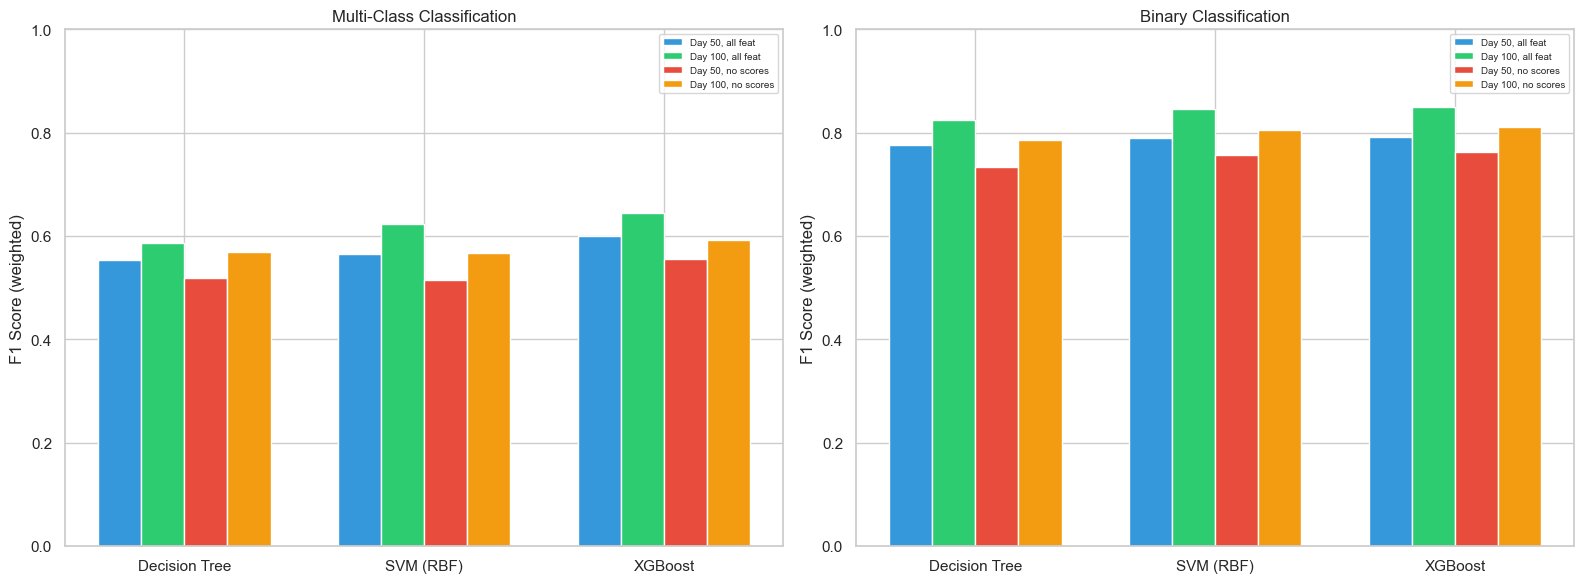

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models = ['Decision Tree', 'SVM (RBF)', 'XGBoost']
experiments = sorted(comparison.Experiment.unique())
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for ax_idx, target in enumerate(['multi-class', 'binary']):
    subset = comparison[comparison.Target == target]
    x = np.arange(len(models))
    width = 0.18
    for i, exp in enumerate(experiments):
        vals = []
        for m in models:
            v = subset[(subset.Model==m) & (subset.Experiment==exp)]['F1 (weighted)']
            vals.append(v.values[0] if len(v)>0 else 0)
        label = exp.split(':')[1].strip()[:25]
        axes[ax_idx].bar(x + i*width, vals, width, label=label, color=bar_colors[i], edgecolor='white')
    axes[ax_idx].set_ylabel('F1 Score (weighted)')
    axes[ax_idx].set_title(f'{target.title()} Classification')
    axes[ax_idx].set_xticks(x + width*1.5)
    axes[ax_idx].set_xticklabels(models)
    axes[ax_idx].legend(fontsize=7)
    axes[ax_idx].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 13.3 Feature Importance (XGBoost)

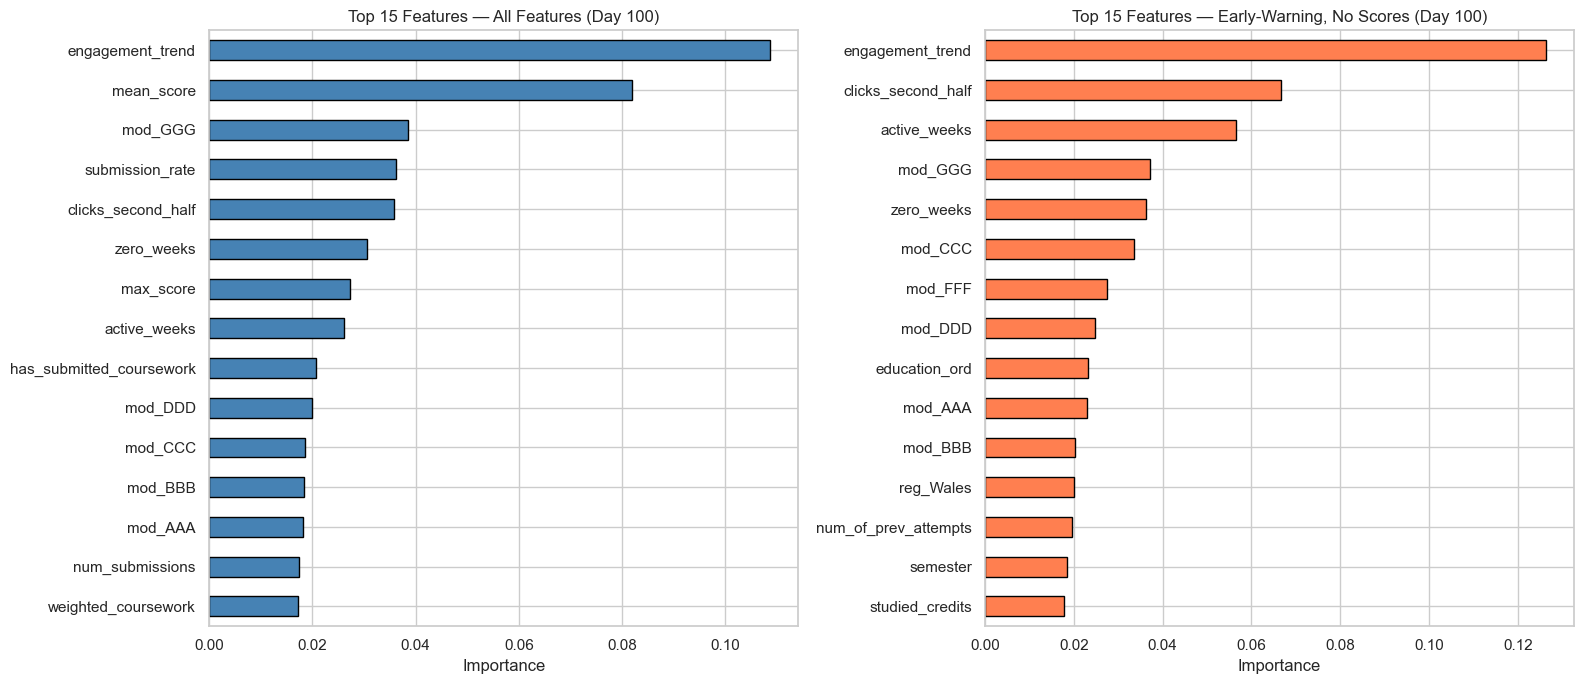

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# All features, day 100
xgb_fi = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',
                             use_label_encoder=False, verbosity=0, **best_xgb_params)
xgb_fi.fit(data_100['X_train'][fs_cols_100], data_100['y_train_m'])
imp = pd.Series(xgb_fi.feature_importances_, index=fs_cols_100).sort_values(ascending=False)
imp.head(15).plot.barh(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 Features — All Features (Day 100)')
axes[0].set_xlabel('Importance'); axes[0].invert_yaxis()

# No scores, day 100
xgb_ew = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',
                             use_label_encoder=False, verbosity=0, **best_xgb_params)
xgb_ew.fit(data_100['X_train'][ew_fs_100], data_100['y_train_m'])
imp_ew = pd.Series(xgb_ew.feature_importances_, index=ew_fs_100).sort_values(ascending=False)
imp_ew.head(15).plot.barh(ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 15 Features — Early-Warning, No Scores (Day 100)')
axes[1].set_xlabel('Importance'); axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Feature importance insights:**

The top feature across both models is **`engagement_trend`** (importance: 0.109) — the ratio of second-half to first-half clicks. This confirms that the *direction* of engagement matters more than the total amount.

In the **all-features model**, `mean_score` (0.082) is the second most important, followed by module indicators and `submission_rate`. Notably, `exam_score` has zero importance at day 100 — almost no students have sat the exam by then, so the feature is uninformative.

In the **no-scores model**, `engagement_trend` remains dominant, followed by weekly trajectory features (`zero_weeks`, `active_weeks`), module indicators, and `clicks_second_half`. The model successfully finds strong behavioural signals without any grade data.

### 13.4 Impact of Prediction Day

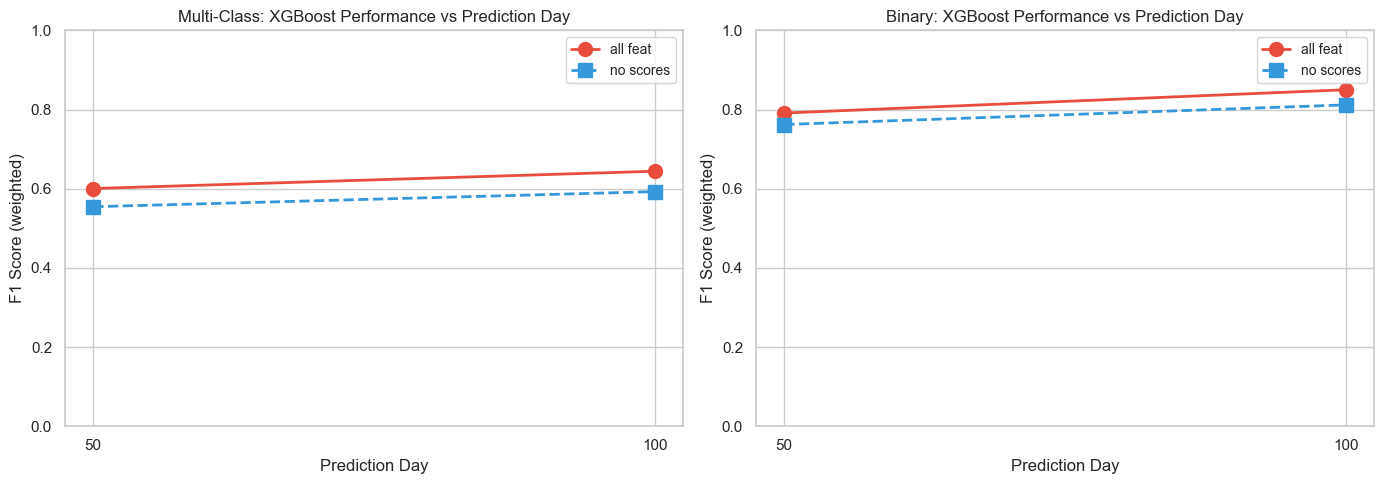

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
days = [50, 100]

for ax_idx, target in enumerate(['multi-class', 'binary']):
    xgb_only = comparison[(comparison.Target == target) & (comparison.Model == 'XGBoost')]
    
    for feat_type, ls, color in [('all feat', '-o', '#e74c3c'), ('no scores', '--s', '#3498db')]:
        vals = []
        for d in days:
            row = xgb_only[xgb_only.Experiment.str.contains(f'Day {d}') & xgb_only.Experiment.str.contains(feat_type)]
            vals.append(row['F1 (weighted)'].values[0] if len(row) > 0 else None)
        if all(v is not None for v in vals):
            axes[ax_idx].plot(days, vals, ls, color=color, label=feat_type, markersize=10, linewidth=2)
    
    axes[ax_idx].set_xlabel('Prediction Day')
    axes[ax_idx].set_ylabel('F1 Score (weighted)')
    axes[ax_idx].set_title(f'{target.title()}: XGBoost Performance vs Prediction Day')
    axes[ax_idx].set_xticks(days)
    axes[ax_idx].legend(fontsize=10)
    axes[ax_idx].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Prediction day analysis:**

Moving from day 50 to day 100 improves XGBoost performance across all setups:

| Setup | Day 50 F1 | Day 100 F1 | Gain |
|---|---|---|---|
| Multi-class, all features | 0.595 | 0.646 | +5.1pp |
| Multi-class, no scores | 0.555 | 0.593 | +3.8pp |
| Binary, all features | 0.793 | 0.849 | +5.6pp |
| Binary, no scores | 0.762 | 0.814 | +5.2pp |

Each additional 50 days of observation adds roughly **4–6 percentage points** of F1 score. This quantifies the tradeoff between prediction accuracy and intervention timing — predicting earlier means less data but more time to act.

## 14. Discussion & Critical Analysis

### Model Performance

**XGBoost consistently outperforms** Decision Tree and SVM (RBF) across all 16 experiment configurations (4 experiments × 2 targets × best model comparison). This is expected — gradient boosting handles feature interactions, mixed feature types, and class imbalance better than either simpler approach.

**SVM (RBF)** performs competitively on binary classification (F1=0.846 vs XGBoost's 0.849 at day 100) but falls behind on multi-class. The RBF kernel captures nonlinear boundaries that are especially useful for separating the overlapping Fail/Withdrawn groups.

**Decision Tree** serves as an interpretable baseline. While its accuracy is lower, it provides clear decision rules that could be directly communicated to academic advisors (e.g., "if engagement_trend < 0.3 and active_weeks < 8, flag as at-risk").

### Hyperparameter Tuning

GridSearchCV and RandomizedSearchCV with GroupKFold identified optimal parameters:
- **Decision Tree:** max_depth=8 with min_samples_leaf=5 prevents overfitting while maintaining expressiveness.
- **SVM (RBF):** C=100, gamma=0.001 — high regularisation strength with a wide kernel, suggesting the decision boundary is relatively smooth in the scaled feature space.
- **XGBoost:** 500 trees, depth 5, learning rate 0.05 — slower learning with more trees, plus strong regularisation (lambda=5, alpha=1.0, gamma=0.3) to prevent overfitting.

A focused second round of XGBoost tuning (150 iterations on a tighter grid with SMOTE) did not improve test performance, suggesting the original parameters are near-optimal for this dataset.

### SMOTE for Class Imbalance

SMOTE oversampling improved multi-class F1 by +0.29pp (0.641 → 0.644) by generating synthetic samples for the underrepresented Distinction class. However, SMOTE slightly hurt binary classification (-0.11pp), where the classes are already nearly balanced (47% vs 53%). We therefore apply SMOTE selectively: multi-class only.

### Feature Selection

Feature importance analysis revealed that `exam_score` and `has_sat_exam` have **zero importance** at day 100. This makes sense — almost no students have sat the exam by the midpoint of the module. Dropping these two features marginally improved F1 (0.641 → 0.646), confirming they were adding noise.

The top feature is **`engagement_trend`** (importance: 0.109), demonstrating that the temporal *direction* of engagement — not just the total amount — is the strongest predictor of outcomes.

### With Scores vs Without Scores (A vs B)

The gap between experiments A and B quantifies how much prediction depends on grades:

| Target | With scores | Without scores | Gap |
|---|---|---|---|
| Multi-class (day 100) | 0.646 | 0.593 | 5.3pp |
| Binary (day 100) | 0.849 | 0.814 | 3.5pp |

The no-scores model achieves **95.9% of the all-features model's binary F1** (0.814 vs 0.849) using only VLE engagement and demographics. This is a strong practical finding: **VLE behaviour alone is sufficient for a useful early-warning system**, even without any grade data.

### Binary vs Multi-Class

Binary classification (Success vs At-Risk) consistently outperforms multi-class by ~20 F1 points. The main difficulty in multi-class is separating **Distinction from Pass** — both groups engage heavily and score well. For practical early-warning systems, binary prediction is recommended: the intervention is the same regardless of whether a student is predicted to Fail or Withdraw.

### Limitations

1. **Score circularity** — Assessment scores partially determine `final_result`, inflating Experiment A accuracy. Experiment B provides the more honest evaluation.
2. **Temporal instability** — Outcome distributions shifted from 2013 to 2014 (withdrawal rates increased). A time-aware train/test split could be explored in future work.
3. **Tuning was not exhaustive** — GridSearchCV and RandomizedSearchCV cover reasonable parameter spaces but are not guaranteed to find the global optimum.
4. **Trajectory features are linear** — The `click_slope` assumes a linear trend in weekly engagement. More sophisticated approaches (e.g., changepoint detection, LSTM on weekly sequences) could capture non-linear disengagement patterns.
5. **IMD imputation on full data** — Mode imputation uses the entire dataset rather than training data only (minimal impact at 3.4% missing).

### Key Takeaways

1. **XGBoost is the best model** across all configurations, with binary F1 up to **0.849** and multi-class F1 up to **0.646**.
2. **VLE engagement alone achieves 81.4% binary F1** — a practical early-warning system is viable without any grade data.
3. **`engagement_trend` is the single most important feature** — the temporal direction of engagement matters more than the total amount of clicks.
4. **Each additional 50 days of observation adds 4–6pp of F1** — there is a clear tradeoff between prediction accuracy and intervention timing.
5. **SMOTE helps multi-class** (+0.29pp) by addressing the Distinction minority class but is unnecessary for binary.
6. **Binary classification is recommended for deployment** — simpler, more accurate (85% vs 65%), and more actionable.
7. **Weekly trajectory features** (click_slope, active_weeks, zero_weeks) contribute meaningful predictive signal beyond simple engagement totals.